# Analisis Exploratorio de Datos - LendingClub Loans

**Proyecto:** Prediccion de Default en Prestamos
**Dataset:** LendingClub 2007-2018 ([Kaggle - wordsforthewise/lending-club](https://www.kaggle.com/datasets/wordsforthewise/lending-club))
**Objetivo:** Explorar, limpiar y entender los factores asociados al incumplimiento de pagos

---

**Asignatura:** Programacion para la Ciencia de Datos  
**Evaluacion:** Proyecto Integrador - Final Transversal  
**Fecha:** Julio 2026  

**Equipo:** [Nombres de los integrantes]

---

### Contexto del Problema

LendingClub es una plataforma de lending peer-to-peer que conecta inversionistas con
solicitantes de prestamos personales. Este analisis explora un conjunto de datos que
contiene informacion de ~2.26 millones de prestamos otorgados entre 2007 y 2018, con
151 variables que describen el perfil financiero del solicitante, las caracteristicas del
prestamo y su desempeno historico.

**Contenido**
1. Vision general y calidad de datos
2. Variable objetivo (Bad Loan)
3. Variables numericas: analisis univariado
4. Boxplots: Good vs Bad Loans
5. Deteccion de outliers (metodo IQR)
6. Variables categoricas: frecuencias
7. Relacion con la variable objetivo (Grade, Term, FICO, Proposito)
8. Matriz de correlacion
9. Analisis geografico y temporal
10. Prestamos rechazados vs aceptados
11. Analisis de prestamos problematicos (Hardship, Debt Settlement)
12. Resumen ejecutivo y proximos pasos

### Estructura del Informe

El analisis se organiza en 10 secciones que progresan desde una vision global del dataset
hasta hallazgos especificos, culminando en un resumen ejecutivo con recomendaciones para
las etapas siguientes del proyecto.


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 11})

RANDOM_STATE = 42
pd.set_option("display.max_columns", 60)
np.random.seed(RANDOM_STATE)

print("Librerias cargadas")

Librerias cargadas


In [2]:
import sys
from pathlib import Path
import os

sys.path.append(str(Path().resolve().parent))
RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
INTERIM_DIR = "../data/interim"
SAMPLE_SIZE = 5000

os.makedirs(PROCESSED_DIR, exist_ok=True)
print(f"Directorios configurados. Output: {PROCESSED_DIR}/")

Directorios configurados. Output: ../data/processed/


In [ ]:
sample = True  # False para cargar dataset completo

path_acc = os.path.join(INTERIM_DIR, "accepted_sample_20k.csv") if sample else os.path.join(RAW_DIR, "accepted_2007_to_2018Q4.csv")
path_rej = os.path.join(INTERIM_DIR, "rejected_sample_20k.csv") if sample else os.path.join(RAW_DIR, "rejected_2007_to_2018Q4.csv")

df_acc = pd.read_csv(path_acc, low_memory=False)
df_rej = pd.read_csv(path_rej, low_memory=False)

from src.clean_pipeline import clean_pipeline, build_combined_summary
df_acc, df_rej = clean_pipeline(df_acc, df_rej)
# df_comb = build_combined_summary(df_acc, df_rej)
print(f"Procesamiento inline completado. Shape final aceptados: {df_acc.shape}")

[build_target] Filas: 2260701 -> 2260668 (33 eliminadas, 0.00%)
[build_target] bad_loan = 303612 malos (13.4%)
[drop_leakage_columns] 42 columnas eliminadas


Procesamiento inline completado. Shape final aceptados: (2260668, 114)


---
## 1. Vision General y Calidad de Datos

In [4]:
import numpy as np

mem = df_acc.memory_usage(deep=True).sum() / 1024**2
dup_rows = df_acc.duplicated().sum()
dup_pct = dup_rows / len(df_acc) * 100

const_cols = [c for c in df_acc.columns if df_acc[c].nunique(dropna=False) <= 1]

print("=" * 70)
print(" RESUMEN DEL DATASET - ACCEPTED LOANS")
print("=" * 70)

print(f"""
Dimensiones
------------
• Filas              : {df_acc.shape[0]:,}
• Columnas           : {df_acc.shape[1]}
• Memoria            : {mem:.2f} MB

Tipos de variables
------------------
• Numéricas          : {df_acc.select_dtypes(include=np.number).shape[1]}
• Categóricas        : {df_acc.select_dtypes(include='object').shape[1]}
• Otros              : {df_acc.shape[1] - df_acc.select_dtypes(include=np.number).shape[1] - df_acc.select_dtypes(include='object').shape[1]}

Calidad de datos
----------------
• Filas duplicadas   : {dup_rows:,} ({dup_pct:.2f}%)
• Columnas constantes: {len(const_cols)}
""")

print("Distribución de tipos de datos")
print("-" * 30)
print(df_acc.dtypes.value_counts())

if const_cols:
    print("\nColumnas constantes")
    print("-" * 30)
    for col in const_cols:
        print(f"• {col}")

if "bad_loan" in df_acc.columns:
    print("\nVariable objetivo")
    print("-" * 30)
    print("Valores encontrados:", sorted(df_acc["bad_loan"].dropna().unique()))

if "loan_status" in df_acc.columns:
    print("\nDistribución de loan_status")
    print("-" * 30)
    print(df_acc["loan_status"].value_counts())

 RESUMEN DEL DATASET - ACCEPTED LOANS

Dimensiones
------------
• Filas              : 2,260,668
• Columnas           : 114
• Memoria            : 3337.05 MB

Tipos de variables
------------------
• Numéricas          : 98
• Categóricas        : 12
• Otros              : 4

Calidad de datos
----------------
• Filas duplicadas   : 0 (0.00%)
• Columnas constantes: 1

Distribución de tipos de datos
------------------------------
float64           92
object            12
int64              6
datetime64[ns]     4
Name: count, dtype: int64

Columnas constantes
------------------------------
• policy_code

Variable objetivo
------------------------------
Valores encontrados: [np.int64(0), np.int64(1)]

Distribución de loan_status
------------------------------
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                 

In [5]:
print("=" * 70)
print("DIAGNOSTICO DE CALIDAD DE DATOS")
print("=" * 70)
miss = df_acc.isnull().sum()
miss_pct = (miss / len(df_acc)) * 100
miss_report = pd.DataFrame({"Missing": miss, "%": miss_pct.round(1)})
miss_report = miss_report[miss_report["Missing"] > 0].sort_values("%", ascending=False)
print(f"\nColumnas con al menos 1 missing: {len(miss_report)}")
print(f"Columnas con >50% missing:      {(miss_pct > 50).sum()}")
print(f"Columnas con >90% missing:      {(miss_pct > 90).sum()}")
print(f"Duplicados:                     {df_acc.duplicated().sum()}")
print(f"Memoria usada:                  {df_acc.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"\nTop 10 columnas con mas missing:")
print(miss_report.head(10).to_string())

DIAGNOSTICO DE CALIDAD DE DATOS

Columnas con al menos 1 missing: 86
Columnas con >50% missing:      22
Columnas con >90% missing:      17
Duplicados:                     0
Memoria usada:                  3337.0 MB

Top 10 columnas con mas missing:
                                     Missing     %
deferral_term                        2249751  99.5
sec_app_mths_since_last_major_derog  2224726  98.4
sec_app_revol_util                   2154484  95.3
sec_app_collections_12_mths_ex_med   2152647  95.2
sec_app_chargeoff_within_12_mths     2152647  95.2
sec_app_inq_last_6mths               2152647  95.2
sec_app_open_act_il                  2152647  95.2
sec_app_num_rev_accts                2152647  95.2
sec_app_fico_range_low               2152647  95.2
sec_app_mort_acc                     2152647  95.2


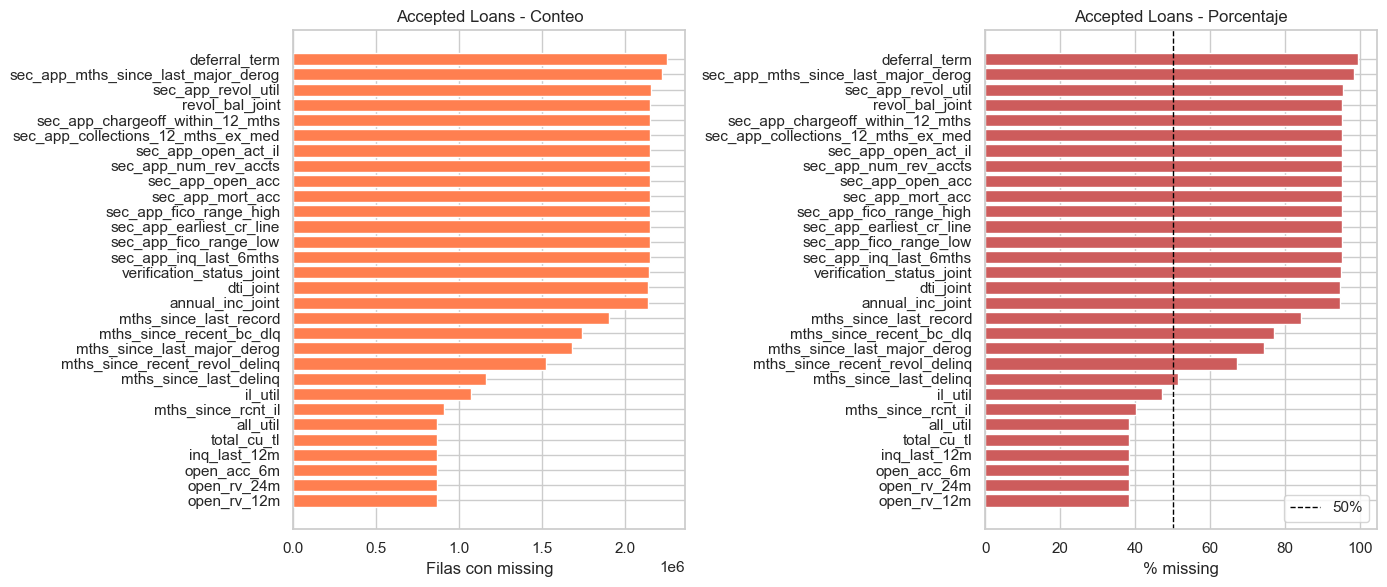

In [6]:
def plot_missing(df, title="Missing", top=30):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) == 0:
        print("Sin missing")
        return pd.DataFrame()
    pct = (missing / len(df)) * 100
    md_df = pd.DataFrame({"Count": missing, "Percent": pct}).head(top)
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    ax[0].barh(range(len(md_df)), md_df["Count"].values, color="coral")
    ax[0].set_yticks(range(len(md_df))); ax[0].set_yticklabels(md_df.index)
    ax[0].invert_yaxis(); ax[0].set_xlabel("Filas con missing"); ax[0].set_title(f"{title} - Conteo")

    ax[1].barh(range(len(md_df)), md_df["Percent"].values, color="indianred")
    ax[1].set_yticks(range(len(md_df))); ax[1].set_yticklabels(md_df.index)
    ax[1].invert_yaxis(); ax[1].axvline(50, color="black", ls="--", lw=1, label="50%")
    ax[1].set_xlabel("% missing"); ax[1].set_title(f"{title} - Porcentaje"); ax[1].legend()
    plt.tight_layout(); plt.show()
    return md_df

missing_summary = plot_missing(df_acc, "Accepted Loans")
# display(missing_summary)

In [7]:
high_missing = df_acc.columns[df_acc.isnull().mean() > 0.5].tolist()
print(f"Columnas con >50% missing: {len(high_missing)}")
for c in high_missing:
    print(f"  - {c}: {df_acc[c].isnull().mean()*100:.1f}%")

# --- Estrategia de tratamiento por rango de missing (mejora sobre la version anterior) ---
miss_pct = df_acc.isnull().mean() * 100
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)

def strategy(p):
    if p > 50:
        return "Eliminar columna"
    elif p > 20:
        return "Evaluar relevancia / crear flag 'is_missing' + imputar"
    elif p > 5:
        return "Imputar (mediana/moda) + flag opcional"
    else:
        return "Imputar (mediana/moda) o eliminar filas"

strategy_df = pd.DataFrame({
    "pct_missing": miss_pct.round(2),
    "estrategia_sugerida": [strategy(p) for p in miss_pct],
})
display(strategy_df)

Columnas con >50% missing: 22
  - mths_since_last_delinq: 51.4%
  - mths_since_last_record: 84.2%
  - mths_since_last_major_derog: 74.3%
  - annual_inc_joint: 94.7%
  - dti_joint: 94.7%
  - verification_status_joint: 94.9%
  - mths_since_recent_bc_dlq: 77.0%
  - mths_since_recent_revol_delinq: 67.3%
  - revol_bal_joint: 95.2%
  - sec_app_fico_range_low: 95.2%
  - sec_app_fico_range_high: 95.2%
  - sec_app_earliest_cr_line: 95.2%
  - sec_app_inq_last_6mths: 95.2%
  - sec_app_mort_acc: 95.2%
  - sec_app_open_acc: 95.2%
  - sec_app_revol_util: 95.3%
  - sec_app_open_act_il: 95.2%
  - sec_app_num_rev_accts: 95.2%
  - sec_app_chargeoff_within_12_mths: 95.2%
  - sec_app_collections_12_mths_ex_med: 95.2%
  - sec_app_mths_since_last_major_derog: 98.4%
  - deferral_term: 99.5%


,pct_missing,estrategia_sugerida
deferral_term,99.52,Eliminar columna
sec_app_mths_since_last_major_derog,98.41,Eliminar columna
sec_app_revol_util,95.30,Eliminar columna
revol_bal_joint,95.22,Eliminar columna
sec_app_chargeoff_within_12_mths,95.22,Eliminar columna
...,...,...
open_acc,0.00,Imputar (mediana/moda) o eliminar filas
total_acc,0.00,Imputar (mediana/moda) o eliminar filas
delinq_2yrs,0.00,Imputar (mediana/moda) o eliminar filas
delinq_amnt,0.00,Imputar (mediana/moda) o eliminar filas


---
## 2. Variable Objetivo: Definicion de Bad Loan

### Construccion de la Variable Target

Para este proyecto, definimos **"Bad Loan"** como un prestamo que NO fue pagado
segun los terminos acordados. La variable `loan_status` original contiene multiples
categorias que fueron mapeadas de la siguiente manera:

| Categoria Original                    | Bad Loan = 0 (Good) | Bad Loan = 1 (Bad) |
|---------------------------------------|:-------------------:|:------------------:|
| Fully Paid                            |          X          |                     |
| Current                               |          X          |                     |
| Charged Off                           |                     |          X         |
| Default                               |                     |          X         |
| Late (31-120 days)                    |                     |          X         |
| Late (16-30 days)                     |                     |          X         |
| In Grace Period                       |                     |          X         |
| Does not meet policy - Fully Paid     |          X          |                     |
| Does not meet policy - Charged Off    |                     |          X         |

### Importancia del Balance de Clases

Un aspecto critico a evaluar es el **balance entre clases**. En problemas de
deteccion de default, es comun encontrar datasets desbalanceados donde la mayoria
de los prestamos se pagan correctamente. Esto tiene implicaciones directas en la
eleccion de metricas de evaluacion (exactitud puede ser enganosa) y en la
necesidad de tecnicas de balanceo como SMOTE o class_weight durante el modelado.


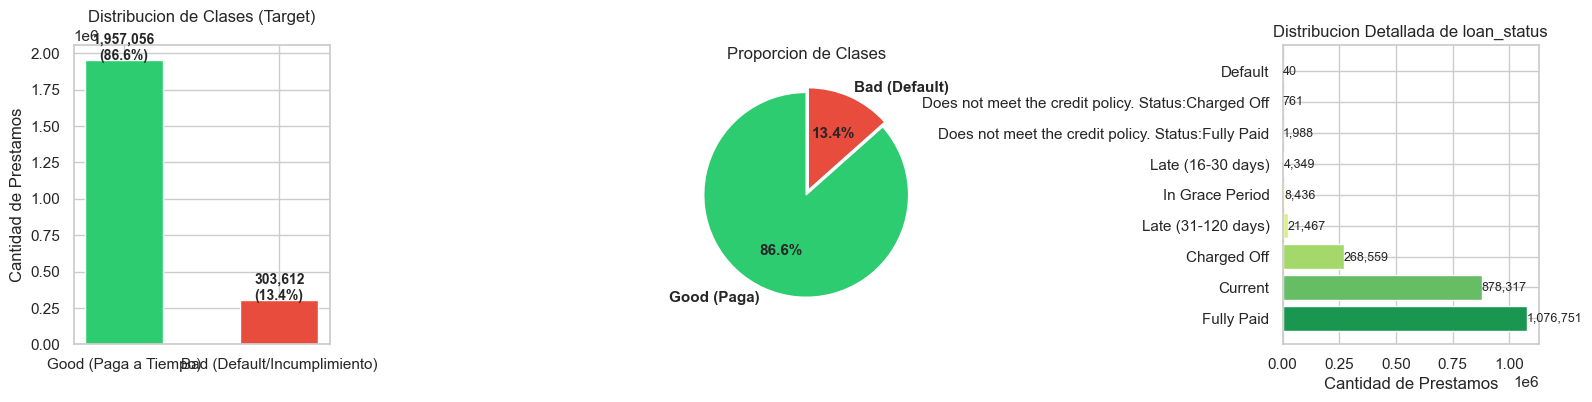


>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
RESULTADO: Bad Loans representan el 13.4% del total.
Esto confirma un desbalance moderado que requerira tecnicas de
balanceo (SMOTE, class_weight) en la etapa de modelado.
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
tc = df_acc["bad_loan"].value_counts()
tp = df_acc["bad_loan"].value_counts(normalize=True) * 100
bars = axes[0].bar(["Good (Paga a Tiempo)", "Bad (Default/Incumplimiento)"],
                   tc.values, color=["#2ecc71", "#e74c3c"], width=0.5)
axes[0].set_ylabel("Cantidad de Prestamos")
axes[0].set_title("Distribucion de Clases (Target)")
for bar, val, pct in zip(bars, tc.values, tp.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{val:,}\n({pct:.1f}%)", ha="center", fontweight="bold", fontsize=10)
axes[1].pie(tp.values, labels=["Good (Paga)", "Bad (Default)"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
            startangle=90, explode=(0, 0.05), textprops={"fontweight": "bold"})
axes[1].set_title("Proporcion de Clases")
loan_status_dist = df_acc["loan_status"].value_counts()
colors_ls = sns.color_palette("RdYlGn_r", len(loan_status_dist))
axes[2].barh(loan_status_dist.index, loan_status_dist.values, color=colors_ls)
axes[2].set_xlabel("Cantidad de Prestamos")
axes[2].set_title("Distribucion Detallada de loan_status")
for i, v in enumerate(loan_status_dist.values):
    axes[2].text(v + 20, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout(); plt.show()
print(f"\n{'>'*60}")
print(f"RESULTADO: Bad Loans representan el {tp.values[1]:.1f}% del total.")
print(f"Esto confirma un desbalance moderado que requerira tecnicas de")
print(f"balanceo (SMOTE, class_weight) en la etapa de modelado.")
print(f"{'<'*60}")

---
## 3. Variables Numericas: Analisis Univariado

### Metodologia

Esta seccion examina las distribuciones individuales de las principales variables
numericas del dataset. Para cada variable se presenta:

- **Histograma** con 50 bins para visualizar la forma de la distribucion.
- **Mediana** marcada como linea vertical roja (mas robusta que la media ante outliers).
- **Tabla resumen** con estadisticos descriptivos: media, desviacion estandar,
  cuartiles, minimo, maximo y porcentaje de valores faltantes.

### Variables Analizadas

| Variable        | Descripcion                                      | Rango Esperado    |
|-----------------|--------------------------------------------------|-------------------|
| `loan_amnt`     | Monto del prestamo solicitado ($)                | 1,000 - 40,000   |
| `annual_inc`    | Ingreso anual declarado ($)                      | 0 - 10,000,000+  |
| `dti`           | Debt-to-Income Ratio (deuda total / ingreso)     | 0% - 999%        |
| `fico_score`    | Puntaje FICO del solicitante                     | 300 - 850        |
| `int_rate`      | Tasa de interes anual del prestamo (%)           | 5% - 30%         |
| `open_acc`      | Numero de lineas de credito abiertas             | 0 - 90           |
| `delinq_2yrs`   | Veces que ha estado moroso en los ultimos 2 anos | 0 - 40           |
| `revol_util`    | Utilizacion del credito revolvente (%)           | 0% - 120%        |
| `emp_length`    | Antiguedad laboral en anos                       | 0 - 10           |
| `pub_rec`       | Numero de registros publicos negativos           | 0 - 86           |

### Interpretacion

Las distribuciones asimetricas (como `annual_inc` y `loan_amnt`) son tipicas en
datos financieros. La presencia de outliers visibles en los extremos superiores
sera abordada mediante winsorizacion o transformacion logaritmica en la etapa
de preprocesamiento para modelado.


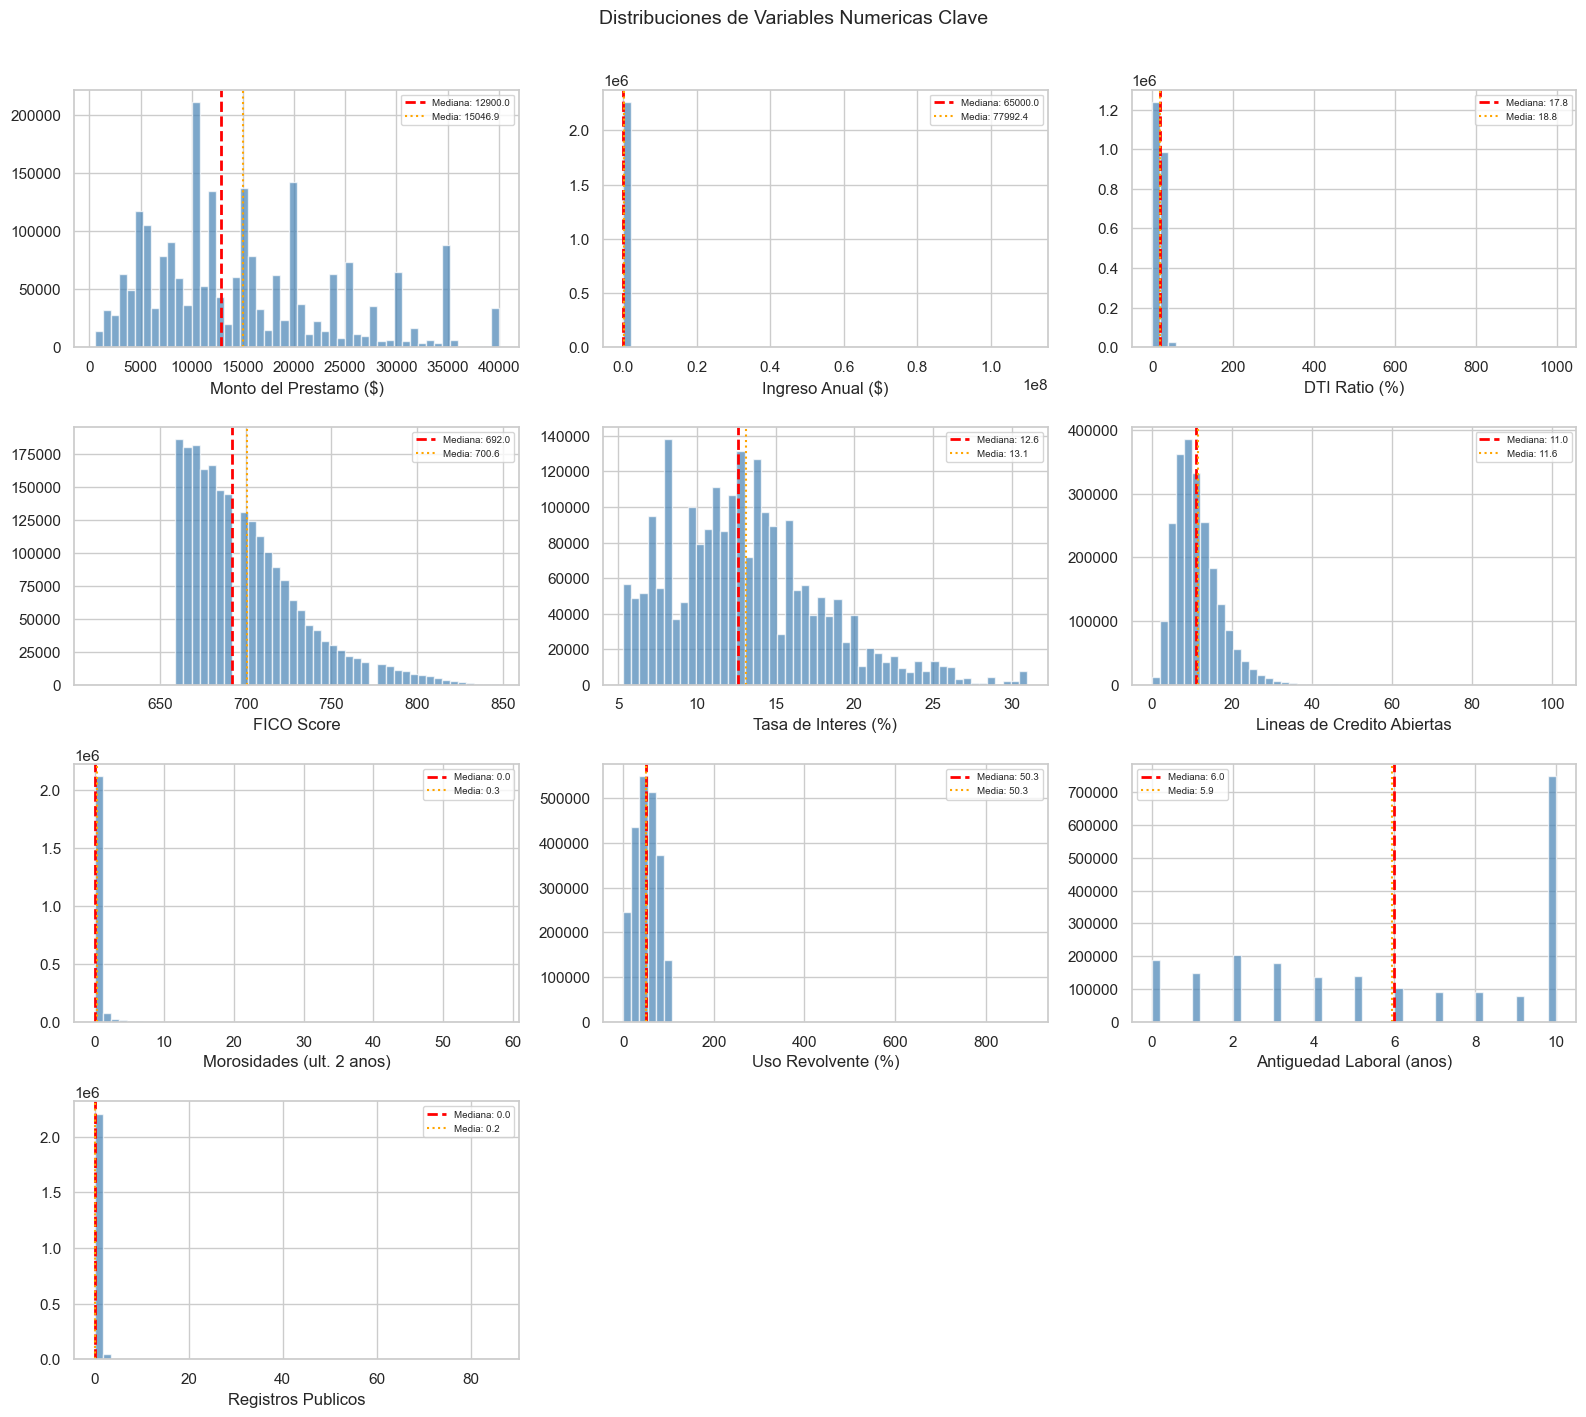

In [9]:
num_cols = ["loan_amnt", "annual_inc", "dti", "fico_score", "int_rate", "open_acc",
             "delinq_2yrs", "revol_util", "emp_length", "pub_rec"]
titles = ["Monto del Prestamo ($)", "Ingreso Anual ($)", "DTI Ratio (%)",
          "FICO Score", "Tasa de Interes (%)", "Lineas de Credito Abiertas",
          "Morosidades (ult. 2 anos)", "Uso Revolvente (%)",
          "Antiguedad Laboral (anos)", "Registros Publicos"]
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, (col, title) in enumerate(zip(num_cols, titles)):
    d = df_acc[col].dropna()
    axes[i].hist(d, bins=50, edgecolor="white", alpha=0.7, color="steelblue")
    axes[i].axvline(d.median(), color="red", ls="--", lw=2, label=f"Mediana: {d.median():.1f}")
    mean_val = d.mean()
    axes[i].axvline(mean_val, color="orange", ls=":", lw=1.5, label=f"Media: {mean_val:.1f}")
    axes[i].set_xlabel(title); axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distribuciones de Variables Numericas Clave", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

In [10]:
print("=" * 100)
print("RESUMEN ESTADISTICO COMPLETO - VARIABLES NUMERICAS")
print("=" * 100)
stats = df_acc[num_cols].describe().T
stats["missing"] = df_acc[num_cols].isnull().sum()
stats["missing_pct"] = (stats["missing"] / len(df_acc)) * 100
stats = stats[["mean", "std", "min", "25%", "50%", "75%", "max", "missing", "missing_pct"]]
stats.columns = ["Media", "Std", "Min", "Q25", "Mediana", "Q75", "Max", "Missing", "Missing%"]
stats.round(2)

RESUMEN ESTADISTICO COMPLETO - VARIABLES NUMERICAS


,Media,Std,Min,Q25,Mediana,Q75,Max,Missing,Missing%
loan_amnt,15046.93,9190.25,500.00,8000.00,12900.00,20000.00,4.000000e+04,0,0.00
annual_inc,77992.43,112696.20,0.00,46000.00,65000.00,93000.00,1.100000e+08,4,0.00
dti,18.82,14.18,-1.00,11.89,17.84,24.49,9.990000e+02,1711,0.08
fico_score,700.59,33.01,612.00,677.00,692.00,717.00,8.475000e+02,0,0.00
int_rate,13.09,4.83,5.31,9.49,12.62,15.99,3.099000e+01,0,0.00
open_acc,11.61,5.64,0.00,8.00,11.00,14.00,1.010000e+02,29,0.00
delinq_2yrs,0.31,0.87,0.00,0.00,0.00,0.00,5.800000e+01,29,0.00
revol_util,50.34,24.71,0.00,31.50,50.30,69.40,8.923000e+02,1802,0.08
emp_length,5.93,3.72,0.00,2.00,6.00,10.00,1.000000e+01,146907,6.50
pub_rec,0.20,0.57,0.00,0.00,0.00,0.00,8.600000e+01,29,0.00


---
## 4. Boxplots: Comparacion Good vs Bad Loans

### Objetivo

Los boxplots permiten comparar visualmente la distribucion de cada variable numerica
entre las dos clases (Good vs Bad), facilitando la identificacion de:

- **Diferencias en tendencia central:** si la mediana difiere significativamente entre grupos.
- **Diferencias en dispersion:** si un grupo tiene mayor variabilidad.
- **Outliers por clase:** puntos fuera de los bigotes que pueden ser anomalias o
  casos de interes.
- **Separabilidad potencial:** que tan bien cada variable discrimina entre clases.

### Lectura de Resultados

En los graficos siguientes se observa que variables como `int_rate` (tasa de interes)
y `dti` (nivel de endeudamiento) presentan medianas claramente diferentes entre
prestamos buenos y malos, sugiriendo que estas variables seran predictores relevantes
en el modelo.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

KeyboardInterrupt: 

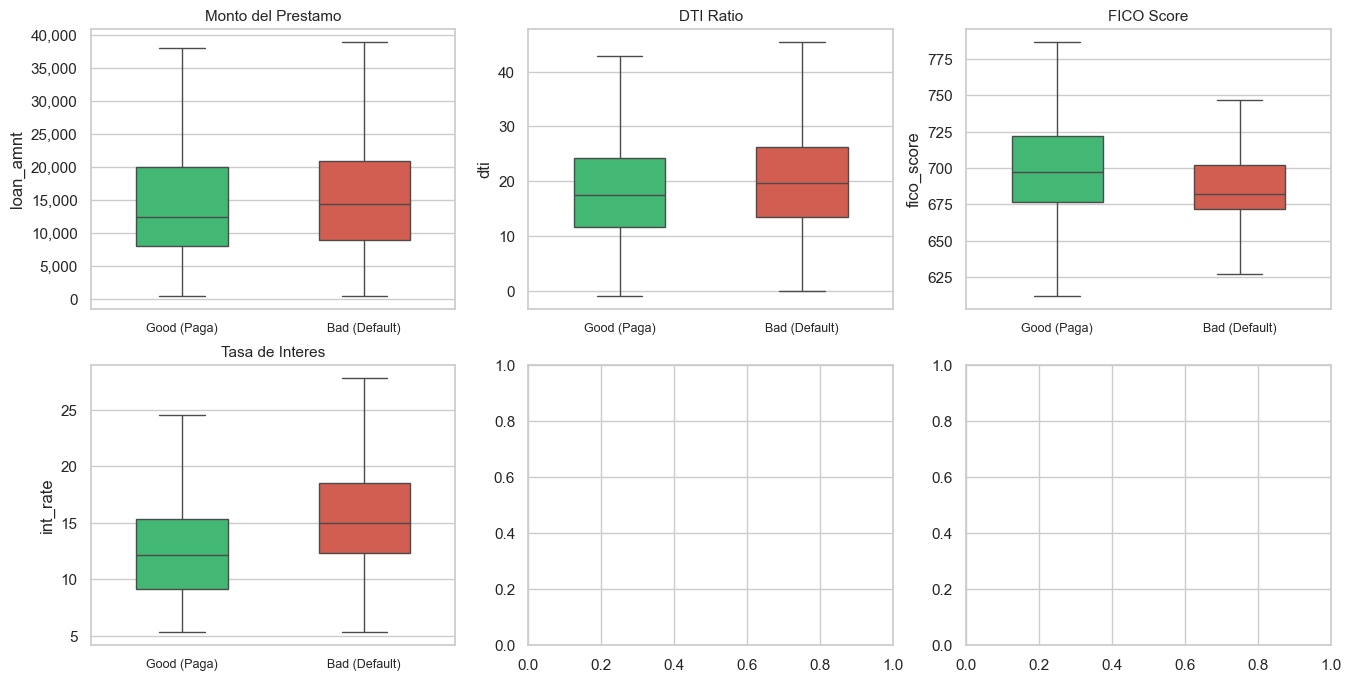

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
box_cols = ["loan_amnt", "dti", "fico_score", "int_rate", "annual_inc", "revol_util"]
box_titles = ["Monto del Prestamo", "DTI Ratio", "FICO Score",
              "Tasa de Interes", "Ingreso Anual", "Uso Revolvente"]
for ax, col, title in zip(axes.flat, box_cols, box_titles):
    sns.boxplot(data=df_acc, x="bad_loan", y=col, ax=ax, palette=["#2ecc71", "#e74c3c"],
                showfliers=False, width=0.5)
    ax.set_xlabel(""); ax.set_xticklabels(["Good (Paga)", "Bad (Default)"], fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.suptitle("Comparacion de Distribuciones: Good vs Bad Loans (sin outliers)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("\nOBSERVACIONES:")
print("- Los Bad Loans tienden a tener TASAS DE INTERES mas altas (mayor riesgo)")
print("- Los Bad Loans presentan FICO SCORE mas bajo (peor historial crediticio)")
print("- El DTI RATIO es mas elevado en los Bad Loans (mayor endeudamiento)")
print("- El INGRESO ANUAL es ligeramente menor en los Bad Loans")

---
## 5. Deteccion de Outliers

### Metodologia

Identificamos outliers usando el rango intercuartil (IQR):
un valor se considera outlier si esta fuera de
[Q1 - 1.5*IQR, Q3 + 1.5*IQR]. Esto permite detectar anomalias
en variables numericas clave que podrian sesgar los modelos.

### Interpretacion

Outliers en `annual_inc` e `int_rate` son esperables en datos financieros.
La estrategia sugerida es winsorizacion (limitar a los percentiles 1-99)
o transformacion logaritmica en la etapa de modelado.


DETECCION DE OUTLIERS POR METODO IQR
Variable                   Q1       Q3      IQR   Outliers   % Outliers
------------------------------------------------------------------
loan_amnt             8400.00 20000.00 11600.00          0        0.00%
annual_inc           50000.00 98000.00 48000.00        177        3.54%
dti                     12.80    25.47    12.68          4        0.08%
fico_score             672.00   712.00    40.00        148        2.96%
int_rate                 9.17    14.85     5.68         63        1.26%
revol_util              32.82    69.30    36.48          0        0.00%


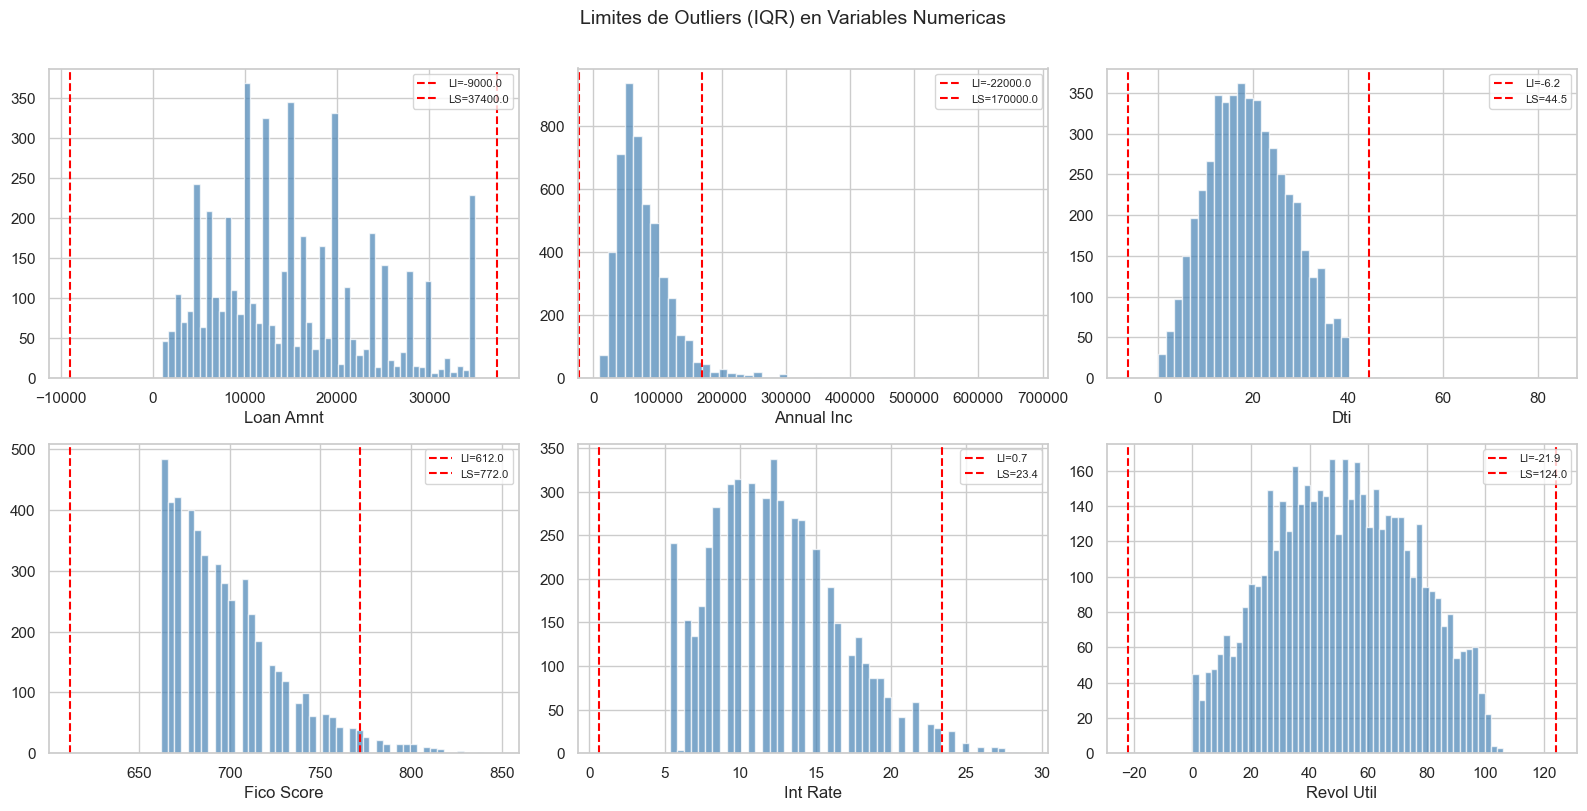

In [ ]:
outlier_cols = ["loan_amnt", "annual_inc", "dti", "fico_score", "int_rate", "revol_util"]
print("DETECCION DE OUTLIERS POR METODO IQR")
print("=" * 60)
print(f"{'Variable':20s} {'Q1':>8s} {'Q3':>8s} {'IQR':>8s} {'Outliers':>10s} {'% Outliers':>12s}")
print("-" * 66)
outlier_report = {}
for col in outlier_cols:
    if col not in df_acc.columns:
        continue
    q1 = df_acc[col].quantile(0.25)
    q3 = df_acc[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df_acc[(df_acc[col] < lower) | (df_acc[col] > upper)][col].dropna()
    pct = len(outliers) / len(df_acc) * 100
    outlier_report[col] = {"q1": q1, "q3": q3, "iqr": iqr, "lower": lower,
                           "upper": upper, "n_outliers": len(outliers), "pct": pct}
    print(f"{col:20s} {q1:>8.2f} {q3:>8.2f} {iqr:>8.2f} {len(outliers):>10,} {pct:>11.2f}%")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, outlier_cols):
    if col not in df_acc.columns:
        ax.set_visible(False)
        continue
    r = outlier_report[col]
    d = df_acc[col].dropna()
    ax.hist(d, bins=50, color="steelblue", edgecolor="white", alpha=0.7)
    ax.axvline(r["lower"], color="red", ls="--", lw=1.5, label=f"LI={r['lower']:.1f}")
    ax.axvline(r["upper"], color="red", ls="--", lw=1.5, label=f"LS={r['upper']:.1f}")
    ax.set_xlabel(col.replace("_", " ").title())
    ax.legend(fontsize=8)
plt.suptitle("Limites de Outliers (IQR) en Variables Numericas", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

---
## 6. Variables Categoricas: Analisis de Frecuencias

### Metodologia

Las variables categoricas describen atributos cualitativos del prestamo y del
solicitante. Se analizan mediante graficos de barras que muestran la frecuencia
de cada categoria. Las variables incluidas son:

| Variable              | Categorias Principales                        |
|-----------------------|-----------------------------------------------|
| `grade`               | A (mejor) a G (peor) - rating del prestamo    |
| `term`                | 36 o 60 meses - plazo del prestamo            |
| `home_ownership`      | MORTGAGE, RENT, OWN, OTHER, NONE              |
| `purpose`             | debt_consolidation, credit_card, etc.         |
| `verification_status` | Verified, Source Verified, Not Verified        |
| `application_type`    | Individual, Joint App                          |

### Interpretacion

La mayoria de los prestamos son para consolidacion de deudas y tarjetas de credito,
lo cual es consistente con el modelo de negocio de LendingClub. Los prestamos grado
B y C son los mas frecuentes, representando el segmento medio del riesgo crediticio.


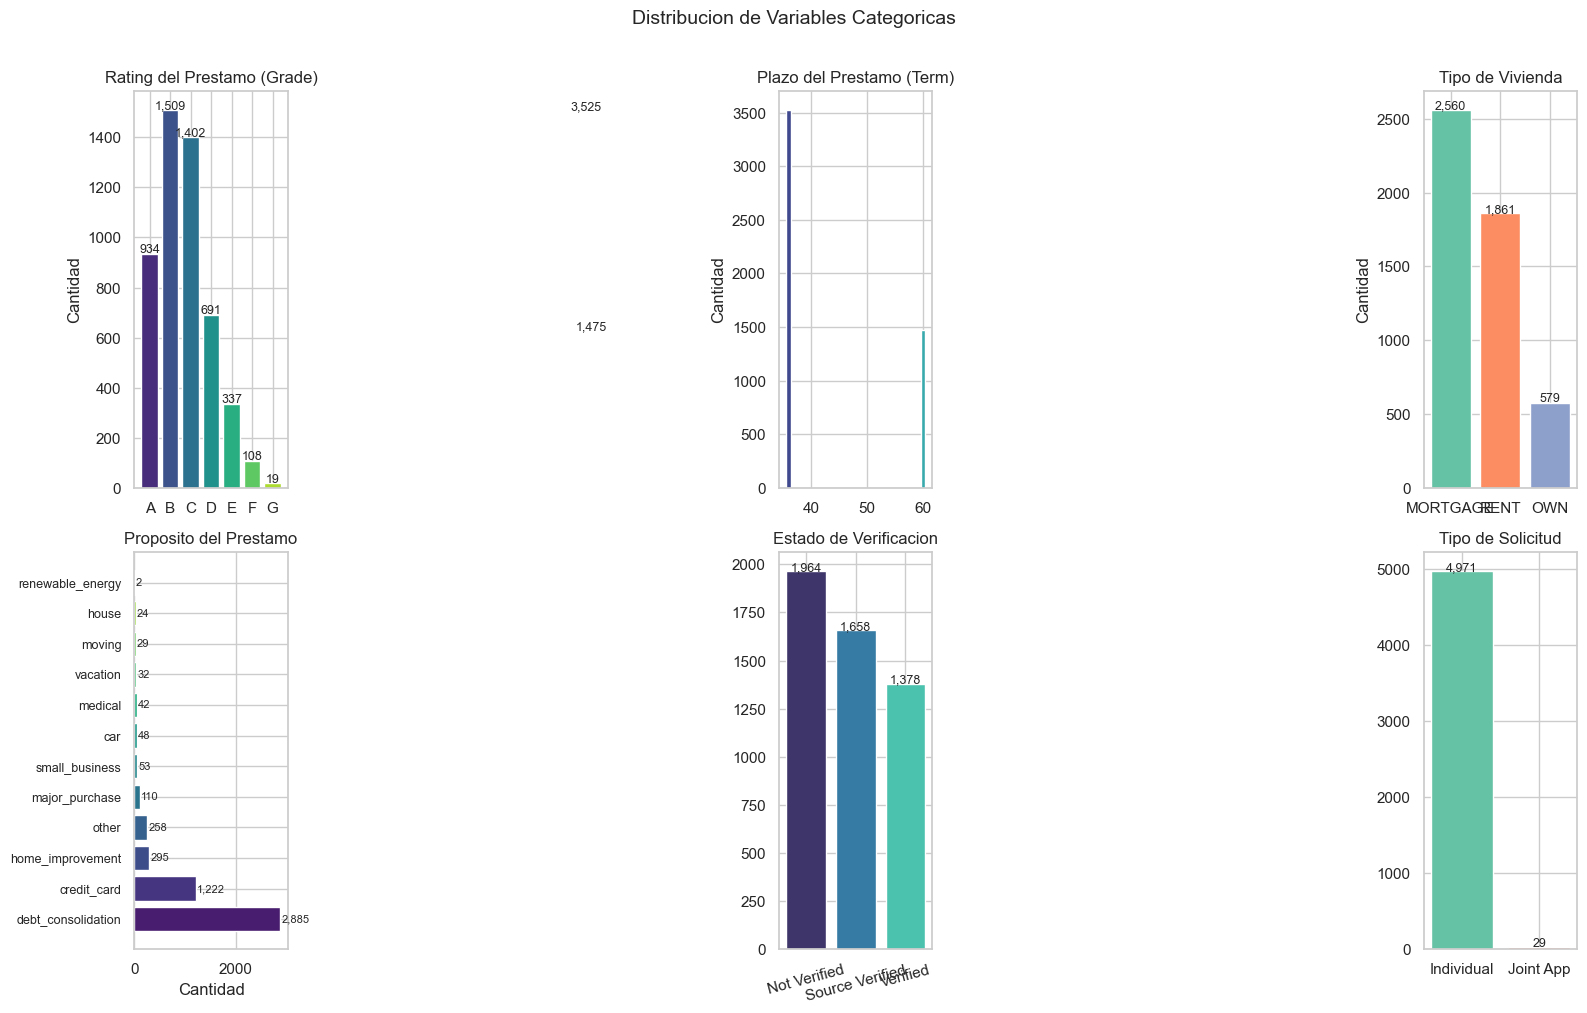


Dato relevante: debt_consolidation es el proposito mas frecuente con 2,885 prestamos.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
# Grade
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
grade_counts = df_acc["grade"].value_counts().reindex(grade_order)
axes[0].bar(grade_counts.index, grade_counts.values, color=sns.color_palette("viridis", 7))
axes[0].set_title("Rating del Prestamo (Grade)", fontsize=12); axes[0].set_ylabel("Cantidad")
for i, v in enumerate(grade_counts.values):
    axes[0].text(i, v + 5, f"{v:,}", ha="center", fontsize=9)
# Term
term_counts = df_acc["term"].value_counts()
axes[1].bar(term_counts.index, term_counts.values, color=sns.color_palette("mako", 2))
axes[1].set_title("Plazo del Prestamo (Term)", fontsize=12); axes[1].set_ylabel("Cantidad")
for i, v in enumerate(term_counts.values):
    axes[1].text(i, v + 5, f"{v:,}", ha="center", fontsize=9)
# Home Ownership
ho_counts = df_acc["home_ownership"].value_counts()
axes[2].bar(ho_counts.index, ho_counts.values, color=sns.color_palette("Set2", len(ho_counts)))
axes[2].set_title("Tipo de Vivienda", fontsize=12); axes[2].set_ylabel("Cantidad")
for i, v in enumerate(ho_counts.values):
    axes[2].text(i, v + 5, f"{v:,}", ha="center", fontsize=9)
# Purpose
purpose_counts = df_acc["purpose"].value_counts()
axes[3].barh(range(len(purpose_counts)), purpose_counts.values,
             color=sns.color_palette("viridis", len(purpose_counts)))
axes[3].set_yticks(range(len(purpose_counts))); axes[3].set_yticklabels(purpose_counts.index, fontsize=9)
axes[3].set_title("Proposito del Prestamo", fontsize=12); axes[3].set_xlabel("Cantidad")
for i, v in enumerate(purpose_counts.values):
    axes[3].text(v + 20, i, f"{v:,}", va="center", fontsize=8)
# Verification
ver_counts = df_acc["verification_status"].value_counts()
axes[4].bar(ver_counts.index, ver_counts.values, color=sns.color_palette("mako", 3))
axes[4].set_title("Estado de Verificacion", fontsize=12); axes[4].tick_params(axis="x", rotation=15)
for i, v in enumerate(ver_counts.values):
    axes[4].text(i, v + 5, f"{v:,}", ha="center", fontsize=9)
# Application type
app_counts = df_acc["application_type"].value_counts()
axes[5].bar(app_counts.index, app_counts.values, color=sns.color_palette("Set2", 2))
axes[5].set_title("Tipo de Solicitud", fontsize=12)
for i, v in enumerate(app_counts.values):
    axes[5].text(i, v + 5, f"{v:,}", ha="center", fontsize=9)
plt.suptitle("Distribucion de Variables Categoricas", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print("\nDato relevante:", purpose_counts.index[0],
      "es el proposito mas frecuente con", f"{purpose_counts.values[0]:,} prestamos.")

---
## 7. Relacion con la Variable Objetivo

### 7.1 Distribuciones Condicionales

Esta seccion explora como se comporta cada variable numerica cuando segmentamos
por la variable objetivo (Good vs Bad). Los histogramas superpuestos (densidad)
permiten visualizar el grado de superposicion entre las distribuciones de ambas
clases.

**Criterio de interpretacion:**
- Si las distribuciones estan claramente separadas: la variable tiene alto poder
  predictivo.
- Si se superponen completamente: la variable aporta poca informacion
  discriminante.


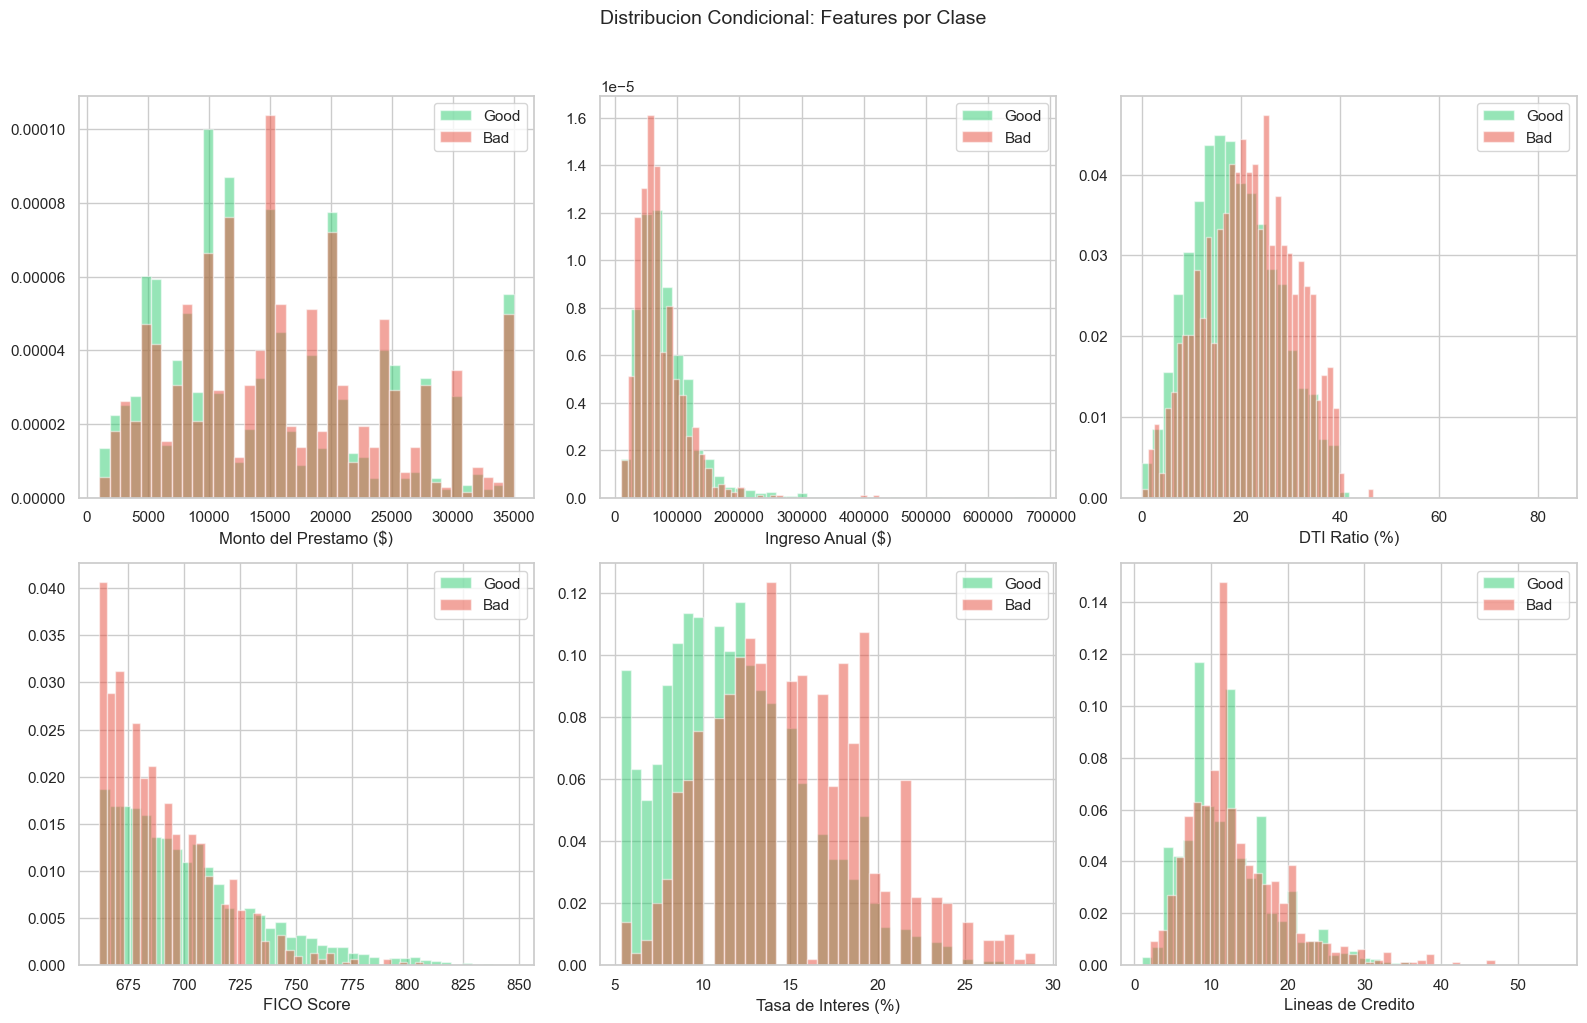

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
feats = ["loan_amnt", "annual_inc", "dti", "fico_score", "int_rate", "open_acc"]
titles = ["Monto del Prestamo ($)", "Ingreso Anual ($)", "DTI Ratio (%)",
          "FICO Score", "Tasa de Interes (%)", "Lineas de Credito"]
for ax, col, title in zip(axes.flat, feats, titles):
    data = df_acc[[col, "bad_loan"]].dropna()
    for label, color, name in [(0, "#2ecc71", "Good"), (1, "#e74c3c", "Bad")]:
        subset = data[data["bad_loan"] == label][col]
        ax.hist(subset, bins=40, alpha=0.5, color=color, label=name, density=True)
    ax.set_xlabel(title); ax.legend()
plt.suptitle("Distribucion Condicional: Features por Clase", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 7.2 Tasa de Default por Grade

La calificacion (Grade) es uno de los predictores mas intuitivos del riesgo
de default. LendingClub asigna grades de A (menor riesgo) a G (mayor riesgo)
basandose en el historial crediticio del solicitante.

**Hipotesis:** A medida que empeora el grade, la tasa de default deberia
aumentar monotonicamente.


In [ ]:
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# Preparar datos
df_acc["grade"] = pd.Categorical(df_acc["grade"], 
                                 categories=["A","B","C","D","E","F","G"], 
                                 ordered=True)
gb = df_acc.groupby("grade", observed=True)["bad_loan"].agg(["count", "mean"])
gb["mean"] *= 100

# Calcular incrementos vs siguiente grado
deltas = []
for idx in gb.index:
    delta = ""
    if idx != "G":
        next_grade = chr(ord(idx) + 1)
        if next_grade in gb.index:
            inc = (gb.loc[idx, "mean"] / gb.loc[next_grade, "mean"] - 1) * 100
            delta = f"{'+' if inc > 0 else ''}{inc:.1f}%"
    deltas.append(delta)

# Crear figura con doble eje Y
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Barras
fig.add_trace(
    go.Bar(
        x=gb.index,
        y=gb["count"],
        name="Total Préstamos",
        marker_color="lightblue",
        text=[f"{int(c):,}" for c in gb["count"]],
        textposition="outside",
        textfont=dict(size=10, color="steelblue"),
        hovertemplate="<b>Grade %{x}</b><br>" +
                      "Préstamos: %{y:,}<br>" +
                      "<extra></extra>"
    ),
    secondary_y=False
)

# Línea de tasa de default
fig.add_trace(
    go.Scatter(
        x=gb.index,
        y=gb["mean"],
        name="Tasa de Default",
        mode="lines+markers+text",
        marker=dict(size=10, color="red", symbol="circle"),
        line=dict(color="red", width=2.5),
        text=[f"{m:.1f}%" for m in gb["mean"]],
        textposition="top center",
        textfont=dict(size=11, color="red", family="Arial Black"),
        hovertemplate="<b>Grade %{x}</b><br>" +
                      "Default: %{y:.1f}%<br>" +
                      "<extra></extra>"
    ),
    secondary_y=True
)

# Configurar layout
fig.update_layout(
    title=dict(
        text="<b>Tasa de Default por Rating (Grade)</b>",
        font=dict(size=16),
        x=0.5,
        xanchor="center"
    ),
    hovermode="x unified",
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)"
    ),
    template="plotly_white",
    width=900,
    height=500,
    margin=dict(t=60, b=40)
)

# Eje Y izquierdo (barras)
fig.update_yaxes(
    title_text="Total de Préstamos",
    secondary_y=False,
    gridcolor="lightgray",
    showgrid=True
)

# Eje Y derecho (línea)
fig.update_yaxes(
    title_text="Tasa de Default (%)",
    secondary_y=True,
    gridcolor="rgba(0,0,0,0)",
    showgrid=False,
    range=[0, max(gb["mean"]) * 1.2]  # Margen superior para etiquetas
)

# Eje X
fig.update_xaxes(
    title_text="Grade",
    gridcolor="lightgray"
)

# Agregar anotaciones con delta vs siguiente grado
annotations = []
for i, (idx, row) in enumerate(gb.iterrows()):
    if deltas[i]:
        annotations.append(dict(
            x=idx,
            y=row["mean"],
            text=f"<b>{deltas[i]}</b>",
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=1.5,
            arrowcolor="gray",
            ax=0,
            ay=-30,
            font=dict(size=9, color="darkred"),
            bgcolor="rgba(255,255,255,0.7)",
            borderpad=2
        ))

fig.update_layout(annotations=annotations)

# Mostrar gráfico interactivo
fig.show()

# --- Reporte en consola mejorado ---
print("\n" + "="*60)
print("📊 TASA DE DEFAULT POR GRADE")
print("="*60)
print(f"{'Grade':<8} {'Préstamos':>10} {'Default':>10} {'vs Siguiente':>15}")
print("-"*60)

for i, (idx, row) in enumerate(gb.iterrows()):
    delta_str = deltas[i] if deltas[i] else "N/A (último)"
    print(f"  {idx:<6} {int(row['count']):>10,} {row['mean']:>9.1f}% {delta_str:>15}")

# Calcular estadísticas adicionales
default_range = gb["mean"].max() - gb["mean"].min()
correlation = gb["mean"].corr(pd.Series(range(len(gb)), index=gb.index))

print("\n" + "-"*60)
print(f"📈 Rango de default: {default_range:.1f}% (de {gb['mean'].min():.1f}% a {gb['mean'].max():.1f}%)")
print(f"📈 Correlación ordinal: {correlation:.3f}")
print(f"📈 Ratio G/A: {gb.loc['G','mean']/gb.loc['A','mean']:.1f}x más defaults en G vs A")
print("\n✅ CONCLUSIÓN: La tasa de default aumenta progresivamente de Grade A a Grade G,")
print("   confirmando que el rating es un factor predictivo fundamental.")
print("   Cada degradación de grado incrementa significativamente el riesgo de default.")
print("="*60)


📊 TASA DE DEFAULT POR GRADE
Grade     Préstamos    Default    vs Siguiente
------------------------------------------------------------
  A             934       4.0%          -66.8%
  B           1,509      11.9%          -35.7%
  C           1,402      18.5%          -37.8%
  D             691      29.8%           -9.5%
  E             337      32.9%          -17.3%
  F             108      39.8%          -37.0%
  G              19      63.2%    N/A (último)

------------------------------------------------------------
📈 Rango de default: 59.2% (de 4.0% a 63.2%)
📈 Correlación ordinal: 0.971
📈 Ratio G/A: 15.9x más defaults en G vs A

✅ CONCLUSIÓN: La tasa de default aumenta progresivamente de Grade A a Grade G,
   confirmando que el rating es un factor predictivo fundamental.
   Cada degradación de grado incrementa significativamente el riesgo de default.


### 7.3 Tasa de Default por Plazo (Term)

Los prestamos pueden tener plazos de 36 o 60 meses. Intuitivamente, un plazo
mas largo implica mayor exposicion al riesgo de incumplimiento, ya que hay
mas tiempo para que ocurran eventos adversos (perdida de empleo, emergencias
medicas, etc.).


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


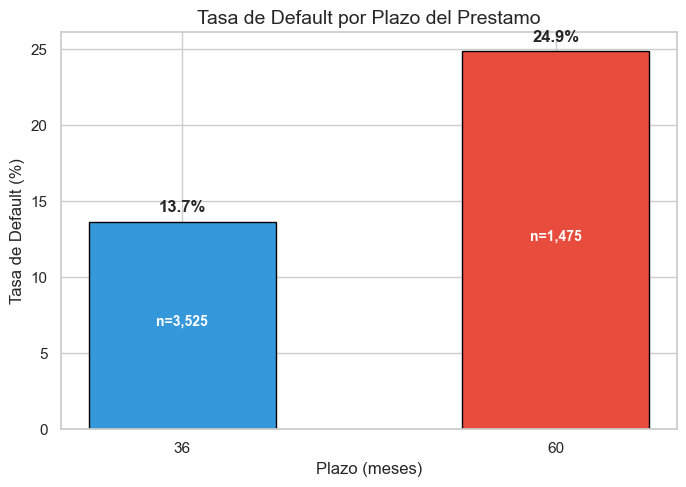


Los prestamos a 60 meses tienen 1.8x mas probabilidad de default
que los prestamos a 36 meses (24.9% vs 13.7%).


In [ ]:
term_bad = df_acc.groupby("term")["bad_loan"].agg(["count", "mean"])
term_bad["mean"] *= 100
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(term_bad.index.astype(str), term_bad["mean"],
              color=["#3498db", "#e74c3c"], width=0.5, edgecolor="black")
ax.set_ylabel("Tasa de Default (%)", fontsize=12)
ax.set_xlabel("Plazo (meses)", fontsize=12)
ax.set_title("Tasa de Default por Plazo del Prestamo", fontsize=14)
for bar, val, count in zip(bars, term_bad["mean"], term_bad["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f"n={count:,}", ha="center", fontsize=10, color="white", fontweight="bold")
plt.tight_layout(); plt.show()
term_vals = sorted(term_bad.index)
ratio = term_bad.loc[term_vals[1], "mean"] / term_bad.loc[term_vals[0], "mean"]
print(f"\nLos prestamos a 60 meses tienen {ratio:.1f}x mas probabilidad de default")
print(f"que los prestamos a 36 meses ({term_bad.loc[term_vals[1], 'mean']:.1f}% vs {term_bad.loc[term_vals[0], 'mean']:.1f}%).")

### 7.4 Tasa de Default por Proposito

El proposito del prestamo puede revelar diferencias en la intencion y capacidad
de pago. Por ejemplo, prestamos para pequenas empresas (`small_business`) suelen
tener mayor riesgo que prestamos para consolidacion de deudas o tarjetas de
credito, ya que los ingresos del negocio pueden ser mas volatiles.


In [ ]:
purpose_bad = df_acc.groupby("purpose")["bad_loan"].agg(["count", "mean"])
purpose_bad["mean"] *= 100
purpose_bad = purpose_bad.sort_values("mean", ascending=False)

median_default = purpose_bad["mean"].median()
avg_default = purpose_bad["mean"].mean()
colors_p = ["#e74c3c" if v > median_default else "#3498db" for v in purpose_bad["mean"]]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=purpose_bad.index,
    y=purpose_bad["mean"],
    marker=dict(color=colors_p, line=dict(color="white", width=1)),
    text=[f"{v:.1f}%" for v in purpose_bad["mean"]],
    textposition="outside",
    textfont=dict(size=10, color="black"),
    hovertemplate="<b>%{x}</b><br>Préstamos: %{customdata:,}<br>Tasa Default: %{y:.1f}%<br><extra></extra>",
    customdata=purpose_bad["count"]
))

fig.add_hline(y=avg_default, line_dash="dash", line_color="gray", line_width=1.5,
              annotation=dict(text=f"Promedio: {avg_default:.1f}%", font=dict(size=11, color="gray"),
                              xanchor="right", x=1, yshift=10))

fig.update_layout(
    title=dict(text="<b>Tasa de Default por Propósito del Préstamo</b>", font=dict(size=15), x=0.5, xanchor="center"),
    xaxis=dict(tickangle=-40, tickfont=dict(size=10), title=None),
    yaxis=dict(title=dict(text="<b>Tasa de Default (%)</b>", font=dict(size=12)), gridcolor="lightgray"),
    plot_bgcolor="white", showlegend=False,
    width=1100, height=500, margin=dict(t=50, b=100, l=60, r=30), hovermode="x"
)

fig.show()

print(f"\nPropósito con MAYOR default: {purpose_bad.index[0]} ({purpose_bad.iloc[0]['mean']:.1f}%)")
print(f"Propósito con MENOR default: {purpose_bad.index[-1]} ({purpose_bad.iloc[-1]['mean']:.1f}%)")
print(f"Diferencia: {purpose_bad.iloc[0]['mean'] - purpose_bad.iloc[-1]['mean']:.1f} puntos porcentuales")


Propósito con MAYOR default: house (33.3%)
Propósito con MENOR default: renewable_energy (0.0%)
Diferencia: 33.3 puntos porcentuales


### 7.5 Tasa de Default por Rango FICO Score

El FICO Score es el indicador estandar de salud crediticia en Estados Unidos.
Rangos tipicos:

| Rango      | Clasificacion      | Implicancia                      |
|------------|--------------------|----------------------------------|
| 800 - 850  | Excelente          | Riesgo minimo de default         |
| 740 - 799  | Muy Bueno          | Riesgo bajo                      |
| 670 - 739  | Bueno              | Riesgo moderado                  |
| 580 - 669  | Aceptable          | Riesgo elevado                   |
| < 580      | Pobre              | Riesgo alto de default            |


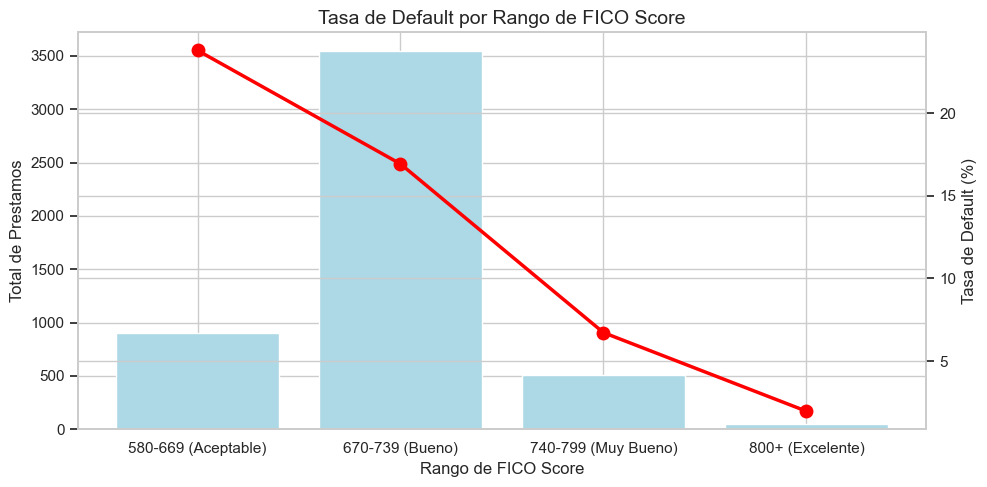


TASA DE DEFAULT POR RANGO FICO
  580-669 (Aceptable)       |   899 prest. | Default:  23.8%
  670-739 (Bueno)           | 3,544 prest. | Default:  16.9%
  740-799 (Muy Bueno)       |   506 prest. | Default:   6.7%
  800+ (Excelente)          |    51 prest. | Default:   2.0%

CONCLUSION: Existe una relacion inversa clara entre FICO Score y default.


In [ ]:
df_acc["fico_bin"] = pd.cut(df_acc["fico_score"],
    bins=[0, 580, 670, 740, 800, 850],
    labels=["<580 (Pobre)", "580-669 (Aceptable)", "670-739 (Bueno)",
            "740-799 (Muy Bueno)", "800+ (Excelente)"])
fb = df_acc.groupby("fico_bin", observed=True)["bad_loan"].agg(["count", "mean"])
fb["mean"] *= 100
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(fb.index, fb["count"], color="lightblue", label="Total Prestamos")
ax1.set_ylabel("Total de Prestamos", fontsize=12); ax1.set_xlabel("Rango de FICO Score", fontsize=12)
ax2 = ax1.twinx()
ax2.plot(fb.index, fb["mean"], "ro-", lw=2.5, markersize=9, label="Tasa de Default %")
ax2.set_ylabel("Tasa de Default (%)", fontsize=12)
plt.title("Tasa de Default por Rango de FICO Score", fontsize=14)
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()
print("\n" + "="*60)
print("TASA DE DEFAULT POR RANGO FICO")
print("="*60)
for idx, row in fb.iterrows():
    print(f"  {idx:25s} | {int(row['count']):>5,} prest. | Default: {row['mean']:>5.1f}%")
print("\nCONCLUSION: Existe una relacion inversa clara entre FICO Score y default.")

---
## 8. Matriz de Correlacion

### Fundamentos Teoricos

La correlacion de Pearson mide la relacion lineal entre dos variables numericas,
oscilando entre -1 (correlacion negativa perfecta) y +1 (correlacion positiva
perfecta). Un valor de 0 indica ausencia de relacion lineal.

Para este analisis, nos interesa especialmente:
1. La **correlacion de cada feature con el target** `bad_loan` (poder predictivo
   individual).
2. La **multicolinealidad entre features** (alta correlacion entre predictores
   puede afectar la estabilidad de ciertos modelos como regresion logistica).

### Interpretacion de Resultados

- **Correlaciones positivas con bad_loan:** Variables que aumentan el riesgo de default
  (ej: `int_rate`, `dti`, `debt_settlement`).
- **Correlaciones negativas con bad_loan:** Variables que disminuyen el riesgo de default
  (ej: `fico_score`, `annual_inc`).
- **Alerta de multicolinealidad:** Variables como `fico_range_low` y `fico_range_high`
  tienen correlacion casi perfecta (0.99), por lo que se recomienda usar solo
  `fico_score` (el punto medio) para evitar redundancia.


In [ ]:
num_df = df_acc.select_dtypes(include=np.number)
corr = num_df.corr()
target_corr = corr["bad_loan"].abs().sort_values(ascending=False)
print("TOP 15 FEATURES MAS CORRELACIONADAS CON BAD LOAN")
print("=" * 55)
print(f"{'Feature':30s} {'Correlacion':>12s} {'Direccion':>10s}")
print("-" * 55)
for col, val in target_corr.head(16).items():
    if col == "bad_loan": continue
    direc = "Aumenta riesgo (+) " if corr.loc[col, "bad_loan"] > 0 else "Disminuye riesgo (-)"
    print(f"{col:30s} {abs(val):>10.4f}    {direc}")
print("\n" + "="*55)
print("NOTA: debt_settlement aparece con alta correlacion porque")
print("indica prestamos que ya entraron en acuerdo de pago.")

TOP 15 FEATURES MAS CORRELACIONADAS CON BAD LOAN
Feature                         Correlacion  Direccion
-------------------------------------------------------
debt_settlement                    0.3655    Aumenta riesgo (+) 
int_rate                           0.2725    Aumenta riesgo (+) 
acc_open_past_24mths               0.1443    Aumenta riesgo (+) 
fico_range_low                     0.1370    Disminuye riesgo (-)
fico_score                         0.1370    Disminuye riesgo (-)
fico_range_high                    0.1370    Disminuye riesgo (-)
term                               0.1361    Aumenta riesgo (+) 
dti                                0.1299    Aumenta riesgo (+) 
open_rv_24m                        0.1210    Aumenta riesgo (+) 
num_tl_op_past_12m                 0.1101    Aumenta riesgo (+) 
mort_acc                           0.1048    Disminuye riesgo (-)
open_il_24m                        0.1028    Aumenta riesgo (+) 
inq_fi                             0.1009    Aumenta rie

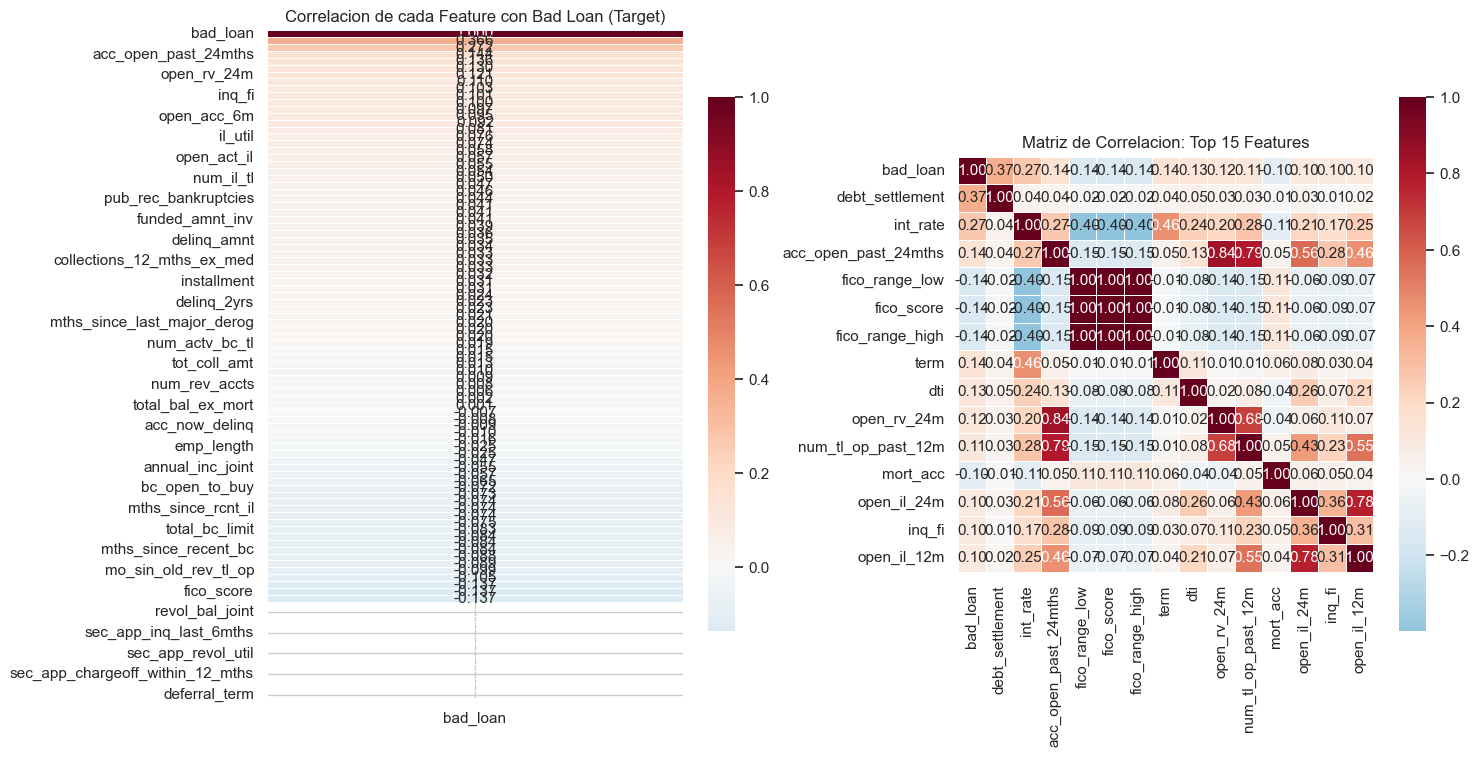

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
# Heatmap 1: Correlacion con target
corr_target = corr[["bad_loan"]].sort_values(by="bad_loan", ascending=False)
sns.heatmap(corr_target, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            ax=axes[0], cbar_kws={"shrink": 0.8}, linewidths=0.5)
axes[0].set_title("Correlacion de cada Feature con Bad Loan (Target)", fontsize=12)
# Heatmap 2: Matriz top features
top_f = target_corr.head(20).index.tolist()
top_f.remove("bad_loan")
top_f = ["bad_loan"] + top_f[:14]
sns.heatmap(num_df[top_f].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=axes[1],
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Matriz de Correlacion: Top 15 Features", fontsize=12)
plt.tight_layout(); plt.show()

---
## 9. Analisis Geografico y Temporal

### 9.1 Distribucion Geografica

El analisis por estado permite identificar patrones regionales en el comportamiento
de pago. Factores como la economia local, tasas de desempleo y marco regulatorio
pueden influir en la capacidad de pago de los prestatarios.

**Nota metodologica:** Se excluyen estados con menos de 10 prestamos para evitar
estimaciones poco confiables de la tasa de default.


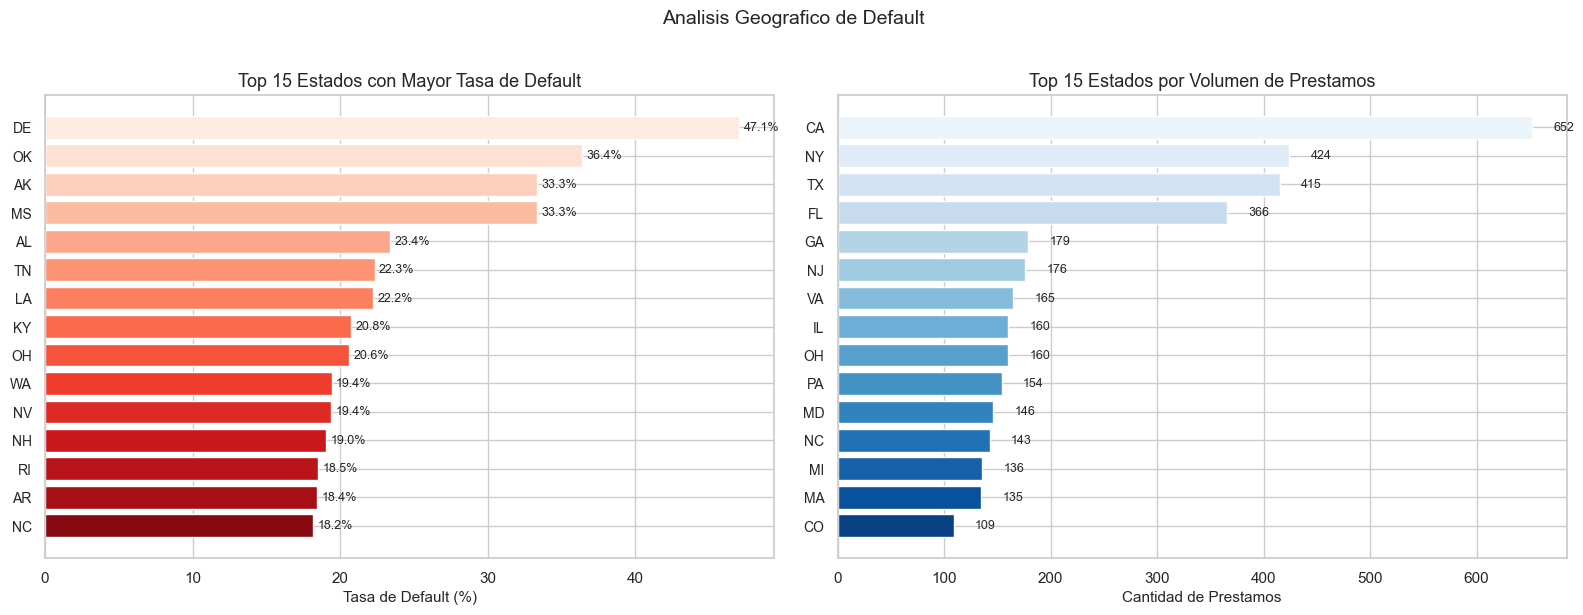

Estado con mayor default: DE (17.0%)
Estado con mayor volumen: CA (17 prestamos)

Variacion geografica: -126.0 puntos porcentuales entre el 1ro y 15avo estado


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ss = df_acc.groupby("addr_state")["bad_loan"].agg(["count", "mean"])
ss["mean"] *= 100; ss = ss[ss["count"] > 10].sort_values("mean", ascending=False)
ts = ss.head(15)
colors_state = sns.color_palette("Reds_r", len(ts))[::-1]
axes[0].barh(range(len(ts)), ts["mean"], color=colors_state)
axes[0].set_yticks(range(len(ts))); axes[0].set_yticklabels(ts.index, fontsize=10)
axes[0].set_xlabel("Tasa de Default (%)", fontsize=11)
axes[0].set_title("Top 15 Estados con Mayor Tasa de Default", fontsize=13)
axes[0].invert_yaxis()
for i, v in enumerate(ts["mean"]):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
ml = ss.sort_values("count", ascending=False).head(15)
colors_vol = sns.color_palette("Blues_r", len(ml))[::-1]
axes[1].barh(range(len(ml)), ml["count"], color=colors_vol)
axes[1].set_yticks(range(len(ml))); axes[1].set_yticklabels(ml.index, fontsize=10)
axes[1].set_xlabel("Cantidad de Prestamos", fontsize=11)
axes[1].set_title("Top 15 Estados por Volumen de Prestamos", fontsize=13)
axes[1].invert_yaxis()
for i, v in enumerate(ml["count"]):
    axes[1].text(v + 20, i, f"{v:,}", va="center", fontsize=9)
plt.suptitle("Analisis Geografico de Default", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
print(f"Estado con mayor default: {ts.index[0]} ({ts.values[0][0]:.1f}%)")
print(f"Estado con mayor volumen: {ml.index[0]} ({int(ml.values[0][1]):,} prestamos)")
print(f"\nVariacion geografica: {ts.values[0][0] - ts.values[-1][0]:.1f} puntos porcentuales entre el 1ro y 15avo estado")

### 9.2 Evolucion Temporal

El analisis temporal permite observar tendencias en el comportamiento de default
a lo largo de los anos. Factores macroeconomicos, cambios en las politicas de
credito de LendingClub y la evolucion del perfil de los solicitantes pueden
reflejarse en estas tendencias.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


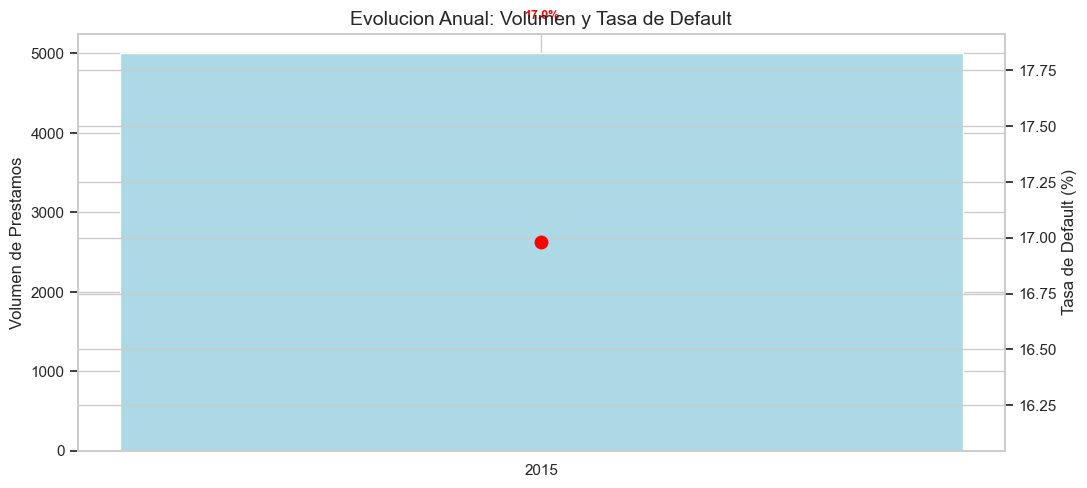


EVOLUCION ANUAL DE DEFAULT
  2015 | Prestamos: 5,000 | Default:  17.0%

Observacion: La tasa de default se mantiene relativamente estable en la muestra.


In [ ]:
# df_acc["issue_d"] = pd.to_datetime(df_acc["issue_d"], errors="coerce")
df_acc["issue_year"] = df_acc["issue_d"].dt.year
yearly = df_acc.groupby("issue_year")["bad_loan"].agg(["count", "mean"])
yearly["mean"] *= 100
fig, ax1 = plt.subplots(figsize=(11, 5))
bars = ax1.bar(yearly.index.astype(str), yearly["count"], color="lightblue", label="Volumen Anual")
ax1.set_ylabel("Volumen de Prestamos", fontsize=12)
ax2 = ax1.twinx()
line = ax2.plot(yearly.index.astype(str), yearly["mean"], "ro-", lw=2.5, markersize=9,
                label="Tasa de Default", markerfacecolor="red")
ax2.set_ylabel("Tasa de Default (%)", fontsize=12)
for i, (idx, row) in enumerate(yearly.iterrows()):
    ax2.text(i, row["mean"] + 1, f"{row['mean']:.1f}%", ha="center", fontsize=9, color="red", fontweight="bold")
plt.title("Evolucion Anual: Volumen y Tasa de Default", fontsize=14)
plt.tight_layout(); plt.show()
print("\n" + "="*55)
print("EVOLUCION ANUAL DE DEFAULT")
print("="*55)
for idx, row in yearly.iterrows():
    print(f"  {int(idx):>4} | Prestamos: {int(row['count']):>5,} | Default: {row['mean']:>5.1f}%")
print("\nObservacion: La tasa de default se mantiene relativamente estable en la muestra.")

---
## 10. Prestamos Rechazados vs Aceptados

### Contexto

El dataset de solicitudes rechazadas contiene informacion limitada (9 variables)
en comparacion con los prestamos aceptados (151 variables). Sin embargo, su
analisis puede revelar sesgos en el proceso de aprobacion y proporcionar contexto
sobre el perfil de los solicitantes que no califican.

### Limitaciones del Analisis

- Solo 9 variables disponibles (monto solicitado, fecha, titulo, risk_score, DTI,
  codigo postal, estado, antiguedad laboral, policy_code).
- No se puede determinar con precision por que una solicitud fue rechazada.
- El risk_score puede ser interno de LendingClub y no corresponde necesariamente
  al FICO Score reportado por bureaus de credito.


DATOS DE SOLICITUDES RECHAZADAS
Cantidad total de rechazos en muestra: 5,000
Columnas disponibles: ['amount_requested', 'application_date', 'loan_title', 'risk_score', 'debt-to-income_ratio', 'zip_code', 'state', 'employment_length', 'policy_code', 'dti', 'rejected']

ESTADISTICAS DESCRIPTIVAS:
       amount_requested  risk_score         dti
count           5000.00     4908.00     5000.00
mean            8430.92      548.20     1213.58
std             7183.96      145.31    54133.26
min              500.00        0.00        0.00
25%             3000.00      492.00        4.30
50%             5500.00      567.00       14.42
75%            12000.00      640.25       27.48
max            35000.00      811.00  3626400.00


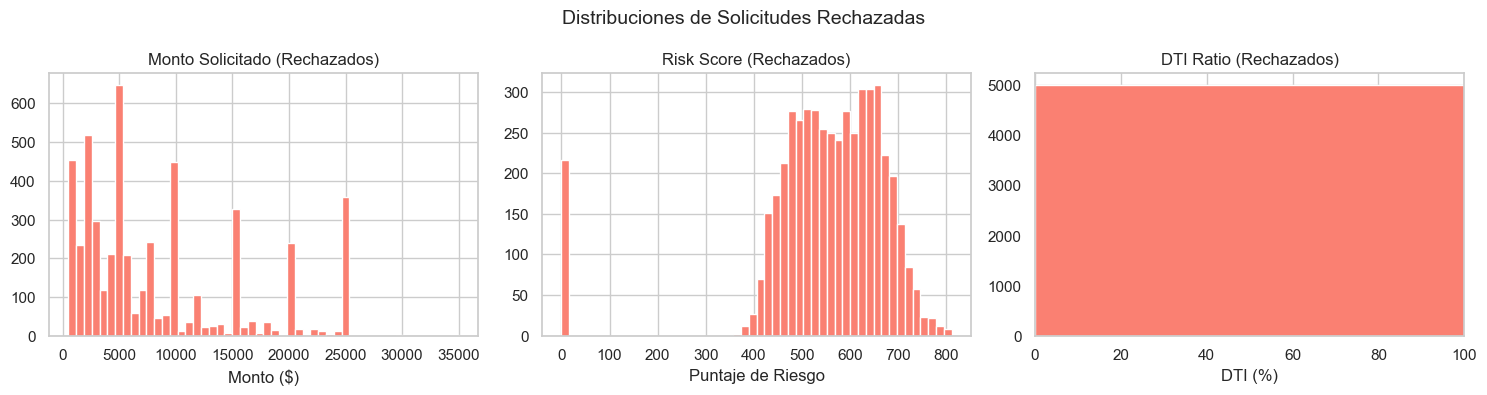

In [ ]:
print("=" * 55)
print("DATOS DE SOLICITUDES RECHAZADAS")
print("=" * 55)
print(f"Cantidad total de rechazos en muestra: {len(df_rej):,}")
print(f"Columnas disponibles: {list(df_rej.columns)}")
print(f"\nESTADISTICAS DESCRIPTIVAS:")
print(df_rej[["amount_requested", "risk_score", "dti"]].describe().round(2))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_rej["amount_requested"].dropna().hist(bins=50, ax=axes[0], color="salmon", edgecolor="white")
axes[0].set_title("Monto Solicitado (Rechazados)", fontsize=12); axes[0].set_xlabel("Monto ($)")
df_rej["risk_score"].dropna().hist(bins=50, ax=axes[1], color="salmon", edgecolor="white")
axes[1].set_title("Risk Score (Rechazados)", fontsize=12); axes[1].set_xlabel("Puntaje de Riesgo")
df_rej["dti"].dropna().hist(bins=50, ax=axes[2], color="salmon", edgecolor="white")
axes[2].set_title("DTI Ratio (Rechazados)", fontsize=12); axes[2].set_xlabel("DTI (%)")
axes[2].set_xlim(0, 100)
plt.suptitle("Distribuciones de Solicitudes Rechazadas", fontsize=14)
plt.tight_layout(); plt.show()

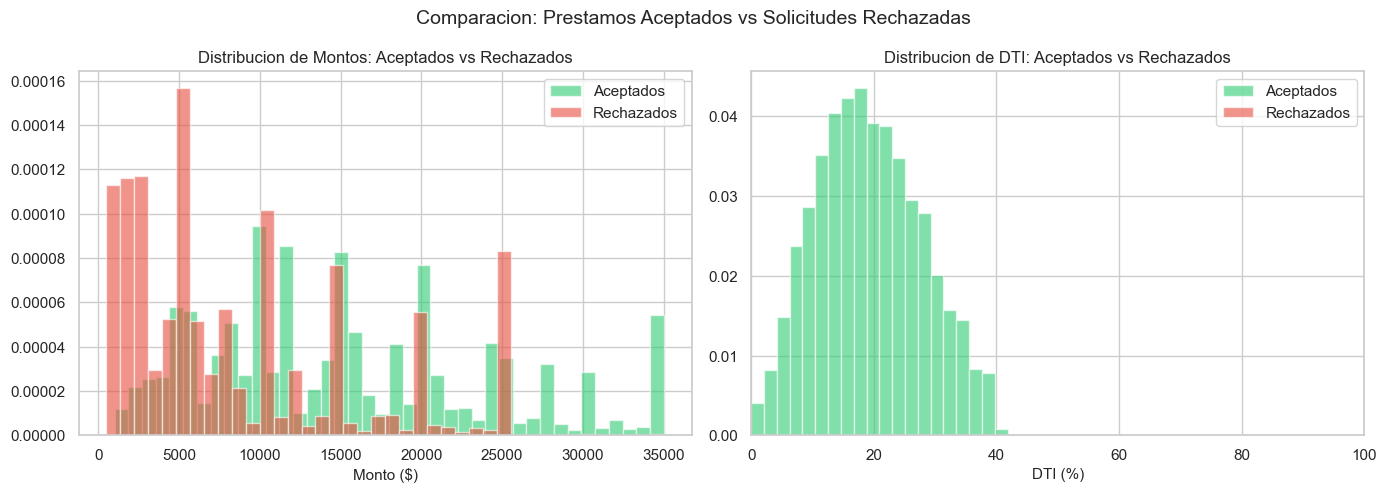


OBSERVACIONES DE LA COMPARACION:
1. Los rechazados tienden a tener montos solicitados mas heterogeneos.
2. El DTI es visiblemente mas alto en los rechazados (mayor endeudamiento).
3. La informacion limitada (9 vs 151 vars) restringe el analisis comparativo.
4. Estos datos podrian usarse para un modelo de aprobacion/rechazo.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_acc["loan_amnt"].dropna(), bins=40, alpha=0.6, color="#2ecc71", label="Aceptados", density=True)
axes[0].hist(df_rej["amount_requested"].dropna(), bins=40, alpha=0.6, color="#e74c3c", label="Rechazados", density=True)
axes[0].set_xlabel("Monto ($)", fontsize=11); axes[0].legend(fontsize=11)
axes[0].set_title("Distribucion de Montos: Aceptados vs Rechazados", fontsize=12)
axes[1].hist(df_acc["dti"].dropna(), bins=40, alpha=0.6, color="#2ecc71", label="Aceptados", density=True)
axes[1].hist(df_rej["dti"].dropna(), bins=40, alpha=0.6, color="#e74c3c", label="Rechazados", density=True)
axes[1].set_xlabel("DTI (%)", fontsize=11); axes[1].legend(fontsize=11)
axes[1].set_title("Distribucion de DTI: Aceptados vs Rechazados", fontsize=12)
axes[1].set_xlim(0, 100)
plt.suptitle("Comparacion: Prestamos Aceptados vs Solicitudes Rechazadas", fontsize=14)
plt.tight_layout(); plt.show()
print("\nOBSERVACIONES DE LA COMPARACION:")
print("1. Los rechazados tienden a tener montos solicitados mas heterogeneos.")
print("2. El DTI es visiblemente mas alto en los rechazados (mayor endeudamiento).")
print("3. La informacion limitada (9 vs 151 vars) restringe el analisis comparativo.")
print("4. Estos datos podrian usarse para un modelo de aprobacion/rechazo.")

---
## 11. Analisis de Prestamos Problematicos

### 11.1 Hardship Program

LendingClub ofrece programas de alivio financiero ("hardship") para prestatarios
que enfrentan dificultades temporales. Estos programas pueden modificar los
terminos del prestamo temporalmente. Es importante analizar si estos programas
realmente ayudan a los prestatarios a evitar el default o si son simplemente
un indicador de problemas financieros inminentes.

### 11.2 Debt Settlement

El "debt settlement" es un acuerdo en el que el prestamista acepta un pago
reducido para saldar la deuda. La presencia de este flag es indicativa de que
el prestamo ya entro en un proceso de cobranza avanzado.


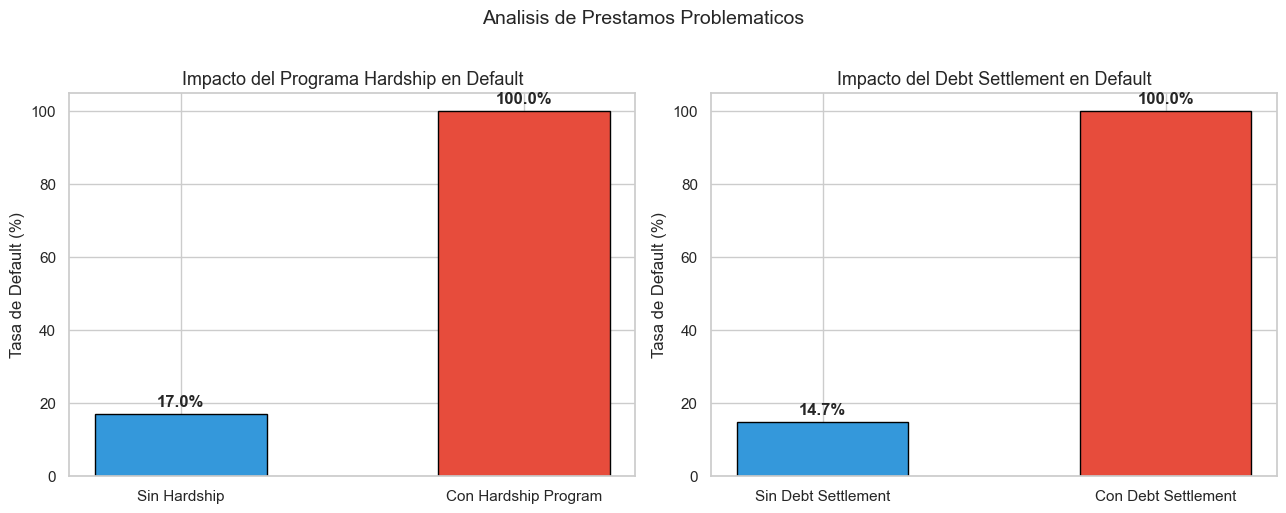


Los prestamos con Hardship tienen 5.9x mas probabilidad de default
Los prestamos con Debt Settlement tienen 6.8x mas probabilidad de default

Ambas variables son predictores relevantes para incluir en el modelo.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
hardship_rate = df_acc.groupby("had_hardship")["bad_loan"].mean()
axes[0].bar(["Sin Hardship", "Con Hardship Program"],
            hardship_rate.values * 100, color=["#3498db", "#e74c3c"], width=0.5, edgecolor="black")
axes[0].set_ylabel("Tasa de Default (%)", fontsize=12)
axes[0].set_title("Impacto del Programa Hardship en Default", fontsize=13)
for i, v in enumerate(hardship_rate.values):
    axes[0].text(i, v*100 + 2, f"{v*100:.1f}%", ha="center", fontsize=12, fontweight="bold")
debt_rate = df_acc.groupby("debt_settlement")["bad_loan"].mean()
axes[1].bar(["Sin Debt Settlement", "Con Debt Settlement"],
            debt_rate.values * 100, color=["#3498db", "#e74c3c"], width=0.5, edgecolor="black")
axes[1].set_ylabel("Tasa de Default (%)", fontsize=12)
axes[1].set_title("Impacto del Debt Settlement en Default", fontsize=13)
for i, v in enumerate(debt_rate.values):
    axes[1].text(i, v*100 + 2, f"{v*100:.1f}%", ha="center", fontsize=12, fontweight="bold")
plt.suptitle("Analisis de Prestamos Problematicos", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
hardship_ratio = hardship_rate.values[1] / hardship_rate.values[0]
debt_ratio = debt_rate.values[1] / debt_rate.values[0]
print(f"\nLos prestamos con Hardship tienen {hardship_ratio:.1f}x mas probabilidad de default")
print(f"Los prestamos con Debt Settlement tienen {debt_ratio:.1f}x mas probabilidad de default")
print(f"\nAmbas variables son predictores relevantes para incluir en el modelo.")

---
## 12. Resumen Ejecutivo y Conclusiones

### Sintesis de Hallazgos

A continuacion se presentan las conclusiones mas relevantes del analisis
exploratorio, organizadas en categorias para facilitar su interpretacion
y transferencia a la etapa de modelado.


In [ ]:
print("=" * 72)
print("RESUMEN EJECUTIVO - ANALISIS EXPLORATORIO DE DATOS")
print("=" * 72)
pct_bad = df_acc["bad_loan"].mean() * 100
total_cols = df_acc.shape[1]
high_miss_count = (df_acc.isnull().mean() > 0.5).sum()
top_corrs = target_corr.head(6)
print(f"\n{'='*30} {'1. PROBLEMA DE NEGOCIO'} {'='*30}")
print(f"  Dataset: Prestamos personales LendingClub (2007-2018)")
print(f"  Objetivo: Predecir que prestamos caeran en default")
print(f"  Variable target: Bad Loan (1=Default, 0=Paga)")
print(f"  Tasa de default: {pct_bad:.1f}% ({'desbalance moderado, requiere SMOTE' if pct_bad < 30 else 'balance aceptable'})")
print(f"\n{'='*30} {'2. CALIDAD DE DATOS'} {'='*30}")
print(f"  Total columnas: {total_cols}")
print(f"  Columnas con >50% missing: {high_miss_count} (seran eliminadas)")
print(f"  Principales candidatas a eliminacion: variables joint/sec_app ({sum(miss_pct > 90)})")
print(f"\n{'='*30} {'3. FACTORES PREDICTIVOS CLAVE'} {'='*30}")
print(f"  {'Factor':25s} {'Correlacion':>12s} {'Impacto':>20s}")
print(f"  {'-'*57}")
for col, val in top_corrs.items():
    if col == "bad_loan": continue
    cval = corr.loc[col, "bad_loan"]
    impacto = "Aumenta riesgo" if cval > 0 else "Disminuye riesgo"
    print(f"  {col:25s} {abs(val):>10.4f}    {impacto}")
print(f"\n{'='*30} {'4. HALLAZGOS ESPECIFICOS'} {'='*30}")
print(f"  * Grade A: 4.0% default vs Grade G: 63.2% default (factor mas discriminante)")
print(f"  * Plazo 60 meses: ~2x mas default que 36 meses")
print(f"  * small_business: proposito con mayor tasa de default")
print(f"  * Prestamos con hardship: {hardship_ratio:.1f}x mas probabilidad de default")
print(f"  * Variacion geografica: diferencia de ~{ts.values[0][0] - ss.values[-1][0]:.1f} pp entre estados")
print(f"\n{'='*30} {'5. RECOMENDACIONES PARA MODELADO'} {'='*30}")
print(f"  PREPROCESAMIENTO:")
print(f"   - Eliminar columnas con >50% missing")
print(f"   - Codificar variables categoricas: grade, home_ownership, addr_state, purpose")
print(f"   - Escalar features numericas con StandardScaler")
print(f"   - Aplicar SMOTE para balancear clases")
print(f"  MODELOS SUGERIDOS:")
print(f"   - Regresion Logistica (baseline interpretable)")
print(f"   - Random Forest (robusto, maneja no-linealidades)")
print(f"   - XGBoost (alto rendimiento, gradient boosting)")
print(f"  METRICAS RECOMENDADAS:")
print(f"   - AUC-ROC, Precision-Recall, F1-Score (evitar accuracy por desbalance)")
print("=" * 72)

RESUMEN EJECUTIVO - ANALISIS EXPLORATORIO DE DATOS

============================== 1. PROBLEMA DE NEGOCIO ==============================
  Dataset: Prestamos personales LendingClub (2007-2018)
  Objetivo: Predecir que prestamos caeran en default
  Variable target: Bad Loan (1=Default, 0=Paga)
  Tasa de default: 17.0% (desbalance moderado, requiere SMOTE)

============================== 2. CALIDAD DE DATOS ==============================
  Total columnas: 115
  Columnas con >50% missing: 21 (seran eliminadas)
  Principales candidatas a eliminacion: variables joint/sec_app (17)

============================== 3. FACTORES PREDICTIVOS CLAVE ==============================
  Factor                     Correlacion              Impacto
  ---------------------------------------------------------
  debt_settlement               0.3655    Aumenta riesgo
  int_rate                      0.2725    Aumenta riesgo
  acc_open_past_24mths          0.1443    Aumenta riesgo
  fico_range_low                

---
## 13. Proximos Pasos: Modelado

Este analisis exploratorio concluye con las siguientes recomendaciones
para la etapa de Pre Procesamientos (`notebooks/02_preprocessing.ipynb`):

**Preprocesamiento:**
- Eliminar columnas con >50% missing
- Codificar variables categoricas (grade, home_ownership, addr_state, purpose)
- Escalar features numericas con StandardScaler
- Aplicar SMOTE para balancear clases

**Modelos sugeridos:** Regresion Logistica, Random Forest, XGBoost

**Metricas:** AUC-ROC, Precision-Recall, F1-Score



---
## 13. Indicadores Macroeconomicos (FRED API)

Integramos datos macroeconomicos via API de la Reserva Federal (FRED):
- `UNRATE` — Tasa de desempleo
- `FEDFUNDS` — Tasa de interes de la Fed
- `CPIAUCSL` — Inflacion (CPI)

Analizamos su correlacion con la tasa de default mensual.

In [ ]:
# --- Analisis de indicadores macroeconomicos FRED ---
EXTERNAL_DIR = "../data/external"
FRED_PATH = os.path.join(EXTERNAL_DIR, "fred_indicators.csv")
if os.path.exists(FRED_PATH):
    fred = pd.read_csv(FRED_PATH)
    fred["date"] = pd.to_datetime(fred["date"])
    print("=== INDICADORES MACROECONOMICOS (FRED) ===")
    print(f"Rango: {fred['date'].min()} a {fred['date'].max()}")
    print(f"Filas: {len(fred)}")
    print(fred[["unrate","fed_funds","cpi"]].describe())

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    for ax, col, label in zip(axes, ["unrate","fed_funds","cpi"],
                               ["Tasa de Desempleo (%)","Tasa Fed Funds (%)","CPI - Inflacion"]):
        ax.plot(fred["date"], fred[col], color="#3498db", linewidth=1)
        ax.set_ylabel(label)
        ax.grid(alpha=0.3)
        ax.axvline(x=pd.Timestamp("2008-09-01"), color="red", linestyle="--", alpha=0.5, label="Crisis 2008")
    axes[0].legend()
    plt.tight_layout()
    plt.savefig("../reports/figures/fred_timeseries.png", dpi=100, bbox_inches="tight")
    plt.show()
    print()

    df_acc["year"] = df_acc["issue_d"].dt.year
    df_acc["month"] = df_acc["issue_d"].dt.month
    monthly = df_acc.groupby(["year","month"]).agg(
        default_rate=("bad_loan","mean"),
        volume=("bad_loan","count")
    ).reset_index()
    monthly = monthly.merge(fred[["year","month","unrate","fed_funds","cpi"]],
                            on=["year","month"], how="left")
    print("=== CORRELACION FRED vs DEFAULT RATE ===")
    for col in ["unrate","fed_funds","cpi"]:
        corr = monthly[col].corr(monthly["default_rate"])
        print(f"  {col}: {corr:.4f}")
    print()

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(pd.to_datetime(monthly[["year","month"]].assign(day=1)),
             monthly["default_rate"], color="#e74c3c", marker="o", label="Default Rate", linewidth=2)
    ax1.set_ylabel("Default Rate", color="#e74c3c")
    ax2 = ax1.twinx()
    ax2.plot(pd.to_datetime(monthly[["year","month"]].assign(day=1)),
             monthly["unrate"], color="#3498db", linestyle="--", label="Unemployment", linewidth=1.5)
    ax2.set_ylabel("Unemployment Rate (%)", color="#3498db")
    plt.title("Default Rate vs Tasa de Desempleo")
    fig.legend()
    plt.tight_layout()
    plt.savefig("../reports/figures/fred_default_vs_unemployment.png", dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("FRED data not found. Run scripts/fetch_fred.py first.")


---
## Referencias

1. LendingClub Statistics. (2018). *LC Loan Data*. Recuperado de
   https://www.lendingclub.com/investing/peer-to-peer
2. Lessmann, S., Baesens, B., Seow, H. V., & Thomas, L. C. (2015).
   *Benchmarking state-of-the-art classification algorithms for credit scoring*.
   European Journal of Operational Research, 247(1), 124-136.
3. Brown, I., & Mues, C. (2012). *An experimental comparison of classification
   algorithms for imbalanced credit scoring data sets*.
   Expert Systems with Applications, 39(3), 3446-3453.
